# Steps

First pass on the steps dataset. It reuses the flat-ground machinery unchanged — Hilbert
phase per leg, binary swing/stance, thorax speed, step cycles opened by either front leg — so
that every measure is comparable with `figure_3.ipynb` and `Headless_vs_Walking_PCA.ipynb`.

**Data.** `stairs_V2/predictions3D/Predictions_3D_20260828-115905/v1/ik_output_combined_v1_free_running.h5`
— 17 bouts, 15,158 frames (18.9 s), native 800. `info/start_frames` gives each bout's absolute
recording frame, which is carried through as `abs_frame` so anything found here can be opened
in the video.


In [1]:
### Setup — paths, imports, constants
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import h5py
from scipy import signal
from scipy.ndimage import gaussian_filter1d
from scipy.signal import hilbert, find_peaks
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

_nb_dir = Path().resolve()
_repo_root = _nb_dir.parent if _nb_dir.name == 'notebooks' else _nb_dir
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))
import utils.io_dict_to_hdf5 as ioh5

# ── data ──────────────────────────────────────────────────────────────────────
STAIRS_DIR = Path('/home/user/src/JARVIS-HybridNet/projects/stairs_V2/predictions/'
                  'predictions3D/Predictions_3D_20260828-115905')
H5_PATH    = STAIRS_DIR / 'v1' / 'ik_output_combined_v1_free_running.h5'
# the sibling *_interpolated.h5 is resampled 800 -> 1000 Hz. This notebook uses the NATIVE
# file, so FPS is the capture rate and no interpolation artefact can be mistaken for a
# kinematic one. Bout lengths here match running_bouts_summary.csv n_frames exactly.
BOUTS_CSV  = STAIRS_DIR / 'running_bouts_summary.csv'
OUTPUT_DIR = Path('/home/user/3D_tracking_paper/stairs_v2')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / 'bout_traces').mkdir(exist_ok=True)

FPS   = 800            # Hz, capture rate of the native file
SCALE = 10.0           # model units -> mm
LEGS  = ['T1_left', 'T1_right', 'T2_left', 'T2_right', 'T3_left', 'T3_right']
LEG_LABELS = {'T1_left': 'L1', 'T1_right': 'R1', 'T2_left': 'L2',
              'T2_right': 'R2', 'T3_left': 'L3', 'T3_right': 'R3'}
LEG_COLORS = {'T1_left': '#1F6FB4', 'T1_right': '#6FA8DC',
              'T2_left': '#B4531F', 'T2_right': '#E0A06F',
              'T3_left': '#2E7D4F', 'T3_right': '#84C39B'}
HEADING_BODIES = ['thorax']
SMOOTH_SIGMA   = 6     # Gaussian sigma (frames) applied to the SPEED, inside
                       # compute_hilbert_phase_bout

# ---- what the swing/stance phase is computed FROM ----
PHASE_SOURCE     = 'world'    # 'ego' | 'world'
EGO_SMOOTH_SIGMA = 4        # Gaussian sigma (frames) on each ego coordinate, before
                            # differentiating. 4 frames = 5 ms at 800 Hz, ~1/10 of a swing.
if PHASE_SOURCE not in ('ego', 'world'):
    raise ValueError(f"PHASE_SOURCE must be 'ego' or 'world', got {PHASE_SOURCE!r}")

# step-cycle definition, same as figure_3: whichever front leg lifts off first in a bout is
# the reference and its OWN next liftoff closes the cycle, so a cycle is a full stride.
REFERENCE_LEG   = 'T1_left'
REFERENCE_LEGS  = ['T1_left', 'T1_right']
MIN_CYCLE_SPEED = 5.0    # mm/s mean thorax speed inside the cycle, else rejected
MIN_CYCLE_MS    = 20.0   # reject near-simultaneous L/R liftoffs

LOCAL_FLOOR_MS  = 220.0   # window for the rolling floor estimate under each foot
LOCAL_FLOOR_PCT = 5.0     # percentile of z inside that window = the local substrate
CONTACT_TOL_MM  = 0.08    # a "stance" whose lowest point stays this far above the local
                          # floor never actually put the foot down
MIN_STANCE_MS   = 40.0    # a stance shorter than this is a detector artefact, not a stance
PEAK_PROM_FRAC  = 0.15    # peak prominence, as a fraction of that swing's own amplitude

print(f'h5      {H5_PATH}')
print(f'         exists: {H5_PATH.exists()}, {H5_PATH.stat().st_size/1e6:.1f} MB')
print(f'figures {OUTPUT_DIR}')


h5      /home/user/src/JARVIS-HybridNet/projects/stairs_V2/predictions/predictions3D/Predictions_3D_20260828-115905/v1/ik_output_combined_v1_free_running.h5
         exists: True, 71.1 MB
figures /home/user/3D_tracking_paper/stairs_v2


In [2]:

# ── Data loading ──────────────────────────────────────────────────────────────
def load_ik_bouts(h5_path):
    d = ioh5.load(h5_path)
    bout_keys    = sorted(k for k in d if k.startswith('bout_'))
    fly_ids      = np.array(d['info']['fly_ids'])
    clip_lengths = np.array(d['info']['clip_lengths'])
    print(f"Loaded {len(bout_keys)} bouts | {len(np.unique(fly_ids))} unique flies")
    print(f"Frames/bout: min={clip_lengths.min()}, max={clip_lengths.max()}, "
          f"total={clip_lengths.sum():,}")
    return d, bout_keys, fly_ids, clip_lengths

_LEG_SHORT = {
    'T1_left':  'T1L', 'T1_right': 'T1R',
    'T2_left':  'T2L', 'T2_right': 'T2R',
    'T3_left':  'T3L', 'T3_right': 'T3R',
}

def find_leg_tip_site_indices(site_names, legs):
    indices = {}
    for leg in legs:
        short = _LEG_SHORT.get(leg, leg)
        patterns = [f"{short}_TaTip", f"{leg}_TaTip", f"claw_{leg}", f"{leg}_claw"]
        match = None
        for p in patterns:
            match = next((i for i, n in enumerate(site_names) if p in n), None)
            if match is not None:
                break
        indices[leg] = match
        if match is None:
            print(f"Warning: no tip site for {leg}")
    return indices

def bouts_to_dataframe(bout_dict, bout_keys, fly_ids, joint_list,
                       names_xpos, heading_bodies,
                       egocentric_site_names, leg_tip_site_indices):
    frames = []
    for bout_idx, (key, fly_id) in enumerate(zip(bout_keys, fly_ids)):
        b    = bout_dict[key]
        xpos = np.array(b['xpos'])
        T    = xpos.shape[0]
        row  = {
            'frame':    np.arange(T),
            'bout_idx': np.full(T, bout_idx, dtype=np.int32),
            'bout_id':  np.full(T, key, dtype=object),
            'fly_id':   np.full(T, fly_id, dtype=object),
        }
        if 'qpos' in b:
            qpos = np.array(b['qpos'])
            for leg, joint, idx in joint_list:
                row[f"{leg}_{joint}"] = qpos[:, idx]
        for body in heading_bodies:
            if body in names_xpos:
                bidx = names_xpos.index(body)
                row[f"{body}_x"] = xpos[:, bidx, 0]
                row[f"{body}_y"] = xpos[:, bidx, 1]
                row[f"{body}_z"] = xpos[:, bidx, 2]
        if 'xpos_egocentric' in b:
            xpos_ego = np.array(b['xpos_egocentric'])
            for leg, site_idx in leg_tip_site_indices.items():
                if site_idx is not None and site_idx < xpos_ego.shape[1]:
                    row[f"{leg}_tip_x_ego"] = xpos_ego[:, site_idx, 0]
                    row[f"{leg}_tip_y_ego"] = xpos_ego[:, site_idx, 1]
                    row[f"{leg}_tip_z_ego"] = xpos_ego[:, site_idx, 2]
        _CLAW_NAMES = {
            'T1_left': 'claw_T1_left', 'T1_right': 'claw_T1_right',
            'T2_left': 'claw_T2_left', 'T2_right': 'claw_T2_right',
            'T3_left': 'claw_T3_left', 'T3_right': 'claw_T3_right',
        }
        for leg, cname in _CLAW_NAMES.items():
            if cname in names_xpos:
                ci = names_xpos.index(cname)
                row[f"{leg}_tip_x_world"] = xpos[:, ci, 0]
                row[f"{leg}_tip_y_world"] = xpos[:, ci, 1]
                row[f"{leg}_tip_z_world"] = xpos[:, ci, 2]
        frames.append(pd.DataFrame(row))
    df = pd.concat(frames, ignore_index=True)
    print(f"Built DataFrame: {len(df):,} frames, {len(df.columns)} columns")
    return df

# ── Preprocessing ─────────────────────────────────────────────────────────────
def _gaussian_smooth(arr, sigma=4):
    mask = np.isnan(arr)
    out  = gaussian_filter1d(np.where(mask, 0., arr), sigma)
    cnt  = gaussian_filter1d((~mask).astype(float), sigma)
    out[cnt > 0] /= cnt[cnt > 0]
    out[mask]     = np.nan
    return out

def swing_onsets_from_stance(series):
    ss = series.values.astype(int)
    return np.where(np.diff(ss, prepend=ss[0]) == -1)[0]

def compute_swing_stance_tip_speed(df, legs, fps=800, thresh_frac=0.20):
    df = df.copy()
    for leg in legs:
        xcol, ycol, zcol = f"{leg}_tip_x_world", f"{leg}_tip_y_world", f"{leg}_tip_z_world"
        if zcol not in df.columns:
            continue
        ss = np.full(len(df), np.nan)
        for _bid, grp in df.groupby('bout_id', sort=False):
            idx = grp.index
            n   = len(grp)
            if n < 5:
                continue
            def _vel(col):
                v = grp[col].values.astype(float) if col in grp.columns else np.zeros(n)
                return np.gradient(v) * fps * 10
            spd = np.sqrt(_vel(xcol)**2 + _vel(ycol)**2 + _vel(zcol)**2)
            spd = _gaussian_smooth(spd, sigma=4)
            thr = thresh_frac * np.nanmax(spd)
            ss[idx] = (spd <= thr).astype(float)
        valid = ~np.isnan(ss)
        df.loc[valid, f"{leg}_swing_stance"] = ss[valid].astype(int)
    return df

def compute_n_legs_stance(df, legs):
    df = df.copy()
    cols = [f"{leg}_swing_stance" for leg in legs if f"{leg}_swing_stance" in df.columns]
    if cols:
        df['n_legs_stance'] = df[cols].sum(axis=1)
    return df

# ── Hilbert phase ─────────────────────────────────────────────────────────────
def compute_hilbert_phase_bout(positions_xyz, fps, smooth_sigma,
                               mask_stance=False, stance_speed_frac=0.20):
    """Per-frame Hilbert phase from 3-D tip speed.

    phase=0: mid-swing (peak speed).  phase=±π: mid-stance.
    Speed is mean-centered before Hilbert so phase spans full [-π, π].
    """
    T = len(positions_xyz)
    if T < 10:
        return np.full(T, np.nan), np.zeros(T)
    xyz = positions_xyz.astype(float).copy()
    for dim in range(3):
        col = xyz[:, dim]
        nans = np.isnan(col)
        if nans.any() and (~nans).sum() > 1:
            col[nans] = np.interp(np.flatnonzero(nans), np.flatnonzero(~nans), col[~nans])
        xyz[:, dim] = col
    vel = np.gradient(xyz, axis=0) * fps
    spd = gaussian_filter1d(np.linalg.norm(vel, axis=1), sigma=smooth_sigma)
    ph  = np.angle(hilbert(spd - np.nanmean(spd)))
    ph[:2] = np.nan; ph[-2:] = np.nan
    if mask_stance:
        ph[spd <= stance_speed_frac * np.nanmax(spd)] = np.nan
    return ph, spd

def swing_onsets_from_hilbert(phase):
    """Detect step-cycle boundaries (mid-swing) from 2π increments in unwrapped Hilbert phase."""
    finite_mask = np.isfinite(phase)
    if finite_mask.sum() < 4:
        return np.array([], dtype=int)
    finite_idx = np.where(finite_mask)[0]
    unwrapped  = np.unwrap(phase[finite_mask])
    jumps = np.where(np.diff(np.floor(unwrapped / (2 * np.pi))) > 0)[0]
    return finite_idx[jumps]

def compute_hilbert_phases(df, legs, fps, smooth_sigma):
    """Compute per-frame Hilbert phase for each leg using world-frame 3-D tip speed.

    Replaces linear-ramp compute_phases_from_swing.
    Convention: phase=0 mid-swing, phase=±π mid-stance.
    Processed per bout to avoid cross-bout edge effects.
    """
    df = df.copy()
    for leg in legs:
        df[f'{leg}_phase'] = np.nan
        x_col = f'{leg}_tip_x_world'
        y_col = f'{leg}_tip_y_world'
        z_col = f'{leg}_tip_z_world'
        if z_col not in df.columns:
            continue
        for bout_id, grp in df.groupby('bout_id', sort=False):
            xyz = grp[[x_col, y_col, z_col]].values
            ph, _ = compute_hilbert_phase_bout(xyz, fps, smooth_sigma, mask_stance=False)
            df.loc[grp.index, f'{leg}_phase'] = ph
    return df

def liftoff_from_hilbert(phase):
    """Upward crossing of phase = -π/2 → liftoff (swing onset)."""
    finite_mask = np.isfinite(phase)
    if finite_mask.sum() < 4:
        return np.array([], dtype=int)
    finite_idx = np.where(finite_mask)[0]
    unwrapped  = np.unwrap(phase[finite_mask])
    increments = np.diff(np.floor((unwrapped + np.pi / 2) / (2 * np.pi)))
    return finite_idx[np.where(increments > 0)[0]]

def landing_from_hilbert(phase):
    """Upward crossing of phase = +π/2 → landing (stance onset)."""
    finite_mask = np.isfinite(phase)
    if finite_mask.sum() < 4:
        return np.array([], dtype=int)
    finite_idx = np.where(finite_mask)[0]
    unwrapped  = np.unwrap(phase[finite_mask])
    increments = np.diff(np.floor((unwrapped - np.pi / 2) / (2 * np.pi)))
    return finite_idx[np.where(increments > 0)[0]]

def compute_swing_stance_from_hilbert(df, legs):
    """Derive binary swing/stance from Hilbert phase.

    swing  (0): |phase| < π/2  — near mid-swing (peak speed)
    stance (1): |phase| >= π/2 — near mid-stance (speed trough)

    Replaces compute_swing_stance_tip_speed. Must be called after
    compute_hilbert_phases.
    """
    df = df.copy()
    for leg in legs:
        phase_col = f'{leg}_phase'
        if phase_col not in df.columns:
            continue
        ph = df[phase_col].values
        ss = np.where(np.isfinite(ph), (np.abs(ph) >= np.pi / 2).astype(float), np.nan)
        df[f'{leg}_swing_stance'] = ss
    return df

def compute_heading_and_velocity(df, fps=800, body='thorax', smooth_sigma=2):
    df = df.copy()
    x_col, y_col = f"{body}_x", f"{body}_y"
    if x_col not in df.columns or y_col not in df.columns:
        print(f"Warning: position columns not found for {body}")
        return df
    heading_arr   = np.full(len(df), np.nan)
    speed_arr     = np.full(len(df), np.nan)
    turn_rate_arr = np.full(len(df), np.nan)
    for bout_id, grp in df.groupby('bout_id'):
        idx = grp.index
        x   = gaussian_filter1d(grp[x_col].values.astype(float), sigma=smooth_sigma)
        y   = gaussian_filter1d(grp[y_col].values.astype(float), sigma=smooth_sigma)
        dx  = np.gradient(x) * fps
        dy  = np.gradient(y) * fps
        heading   = np.arctan2(dy, dx)
        heading_u = np.unwrap(heading)
        heading_s = gaussian_filter1d(heading_u, sigma=smooth_sigma)
        heading_s = (heading_s + np.pi) % (2 * np.pi) - np.pi
        heading_arr[idx]   = heading_s
        speed_arr[idx]     = np.sqrt(dx**2 + dy**2) * 10   # mm/s
        turn_rate_arr[idx] = np.gradient(heading_s) * fps
    df['heading']       = heading_arr
    df['forward_speed'] = speed_arr
    df['turning_rate']  = turn_rate_arr
    return df

def compute_step_cycle_speed(df, fps=800, ref_legs=None,
                             min_speed=None, min_ms=None):
    """Step cycles bounded by liftoffs of EITHER front leg, gated on body speed.

    Two changes from the earlier version, which used T1_left liftoffs only and
    accepted every cycle it found:

    1. EITHER front leg can initiate. Per bout, the leg that lifts off first
       becomes the reference, and each cycle runs from one of ITS liftoffs to the
       next -- a full stride, median 94 ms. Which leg leads is close to a coin
       flip across bouts (T1_left 1116, T1_right 1110), and letting the leading
       leg define the cycle recovers 5701 cycles against 5201 for T1_left only:
       in a right-led bout, T1_left's first liftoff comes later and the opening
       stride was being lost. `step_cycle_leg` records the reference leg.
       NOTE: this is NOT a merge of both legs' liftoffs. Merging would bound each
       cycle by the OTHER leg's next liftoff, halving it to ~46 ms, because the
       front legs run in near-perfect antiphase (L->R offset 0.500 of the stride,
       IQR 0.454-0.557).

    2. A cycle is kept only if mean thorax speed inside it exceeds `min_speed`.
       The Hilbert phase has no amplitude gate, so a standing fly still
       accumulates 2*pi and still yields liftoffs: bout_0807 reported 14 of them
       with the body moving for exactly one. Cycles shorter than `min_ms` are
       dropped too -- those are near-simultaneous L/R events, not steps.
    """
    df = df.copy()
    ref_legs  = REFERENCE_LEGS  if ref_legs  is None else ref_legs
    min_speed = MIN_CYCLE_SPEED if min_speed is None else min_speed
    min_ms    = MIN_CYCLE_MS    if min_ms    is None else min_ms

    sc_id  = np.full(len(df), np.nan)
    sc_spd = np.full(len(df), np.nan)
    sc_leg = np.full(len(df), '', dtype=object)
    n_kept = n_slow = n_short = 0

    for bout_id, grp in df.groupby('bout_id', sort=False):
        idx = grp.index
        per_leg = {}
        for leg in ref_legs:
            pcol = f'{leg}_phase'
            if pcol in grp.columns:
                on = liftoff_from_hilbert(grp[pcol].values)
                if len(on):
                    per_leg[leg] = on
        if not per_leg:
            continue
        # whichever leg lifts off FIRST in this bout defines the cycles, and each
        # cycle is closed by that SAME leg's next liftoff -- so a cycle is a full
        # stride, not a half-stride. Ties fall to the order of ref_legs.
        ref = min(per_leg, key=lambda l: per_leg[l][0])
        onsets = per_leg[ref]
        if len(onsets) < 2:
            continue
        events = [(int(t), ref) for t in onsets]
        spd = (grp['forward_speed'].values.astype(float)
               if 'forward_speed' in grp.columns else np.full(len(grp), np.nan))
        k = 0
        for (t0, leg), (t1, _) in zip(events[:-1], events[1:]):
            if (t1 - t0) / fps * 1000.0 < min_ms:
                n_short += 1
                continue
            mspd = np.nanmean(spd[t0:t1])
            if not np.isfinite(mspd) or mspd < min_speed:
                n_slow += 1
                continue
            sc_id[idx[t0:t1]]  = k
            sc_spd[idx[t0:t1]] = mspd
            sc_leg[idx[t0:t1]] = leg
            k += 1
            n_kept += 1

    df['step_cycle_id']         = sc_id
    df['step_cycle_mean_speed'] = sc_spd
    df['step_cycle_leg']        = sc_leg
    print(f"Step cycles: {n_kept} kept from legs {ref_legs}"
          f" | rejected {n_slow} below {min_speed} mm/s thorax speed,"
          f" {n_short} shorter than {min_ms:.0f} ms")
    return df



In [3]:
# ---- Build df_valid: one row per frame, per bout ----
bout_dict, bout_keys, fly_ids, clip_lengths = load_ik_bouts(H5_PATH)
names_qpos            = list(bout_dict['info']['names_qpos'])
names_xpos            = list(bout_dict['info']['names_xpos'])
egocentric_site_names = list(bout_dict['info']['site_names_egocentric'])
START_FRAMES = np.array(bout_dict['info']['start_frames']).astype(int)

# ---- the egocentric positions are computed here, NOT read from the h5 ----
def add_ego_from_xpos(bout_dict, bout_keys, names_xpos, df):
    """Merge {leg}_{x,y,z}_ego: claw position in the THORAX body frame, model units."""
    th = names_xpos.index('thorax')
    ci = {l: names_xpos.index(f'claw_{l}') for l in LEGS}
    rows = []
    for key in bout_keys:
        b = bout_dict[key]
        X = np.asarray(b['xpos'], dtype=float)
        q = np.asarray(b['xquat'], dtype=float)[:, th]
        w, x, y, z = q.T
        R = np.stack([                        # body -> world, so R^T maps world -> body
            np.stack([1 - 2*(y*y + z*z), 2*(x*y - w*z), 2*(x*z + w*y)], -1),
            np.stack([2*(x*y + w*z), 1 - 2*(x*x + z*z), 2*(y*z - w*x)], -1),
            np.stack([2*(x*z - w*y), 2*(y*z + w*x), 1 - 2*(x*x + y*y)], -1)], -2)
        Rt = np.transpose(R, (0, 2, 1))
        r = {'bout_id': key, 'frame': np.arange(len(X))}
        for l in LEGS:
            v = np.einsum('tij,tj->ti', Rt, X[:, ci[l]] - X[:, th])
            for a, k in zip('xyz', range(3)):
                r[f'{l}_tip_{a}_ego'] = v[:, k]
        rows.append(pd.DataFrame(r))
    t = pd.concat(rows, ignore_index=True)
    return df.merge(t, on=['bout_id', 'frame'], how='left', validate='one_to_one')

df = bouts_to_dataframe(bout_dict, bout_keys, fly_ids, joint_list=[],
                        names_xpos=names_xpos, heading_bodies=HEADING_BODIES,
                        egocentric_site_names=[], leg_tip_site_indices={})
df = add_ego_from_xpos(bout_dict, bout_keys, names_xpos, df)

# the check, against the h5's own array, so the discrepancy is on the record
_EI = {'T1_left': 18, 'T1_right': 25, 'T2_left': 31,
       'T2_right': 37, 'T3_left': 43, 'T3_right': 49}
print('egocentric z: recomputed here vs the h5 xpos_egocentric it replaces')
print(f'{"leg":>4}{"r":>8}{"h5 std":>10}{"ours std":>10}   (mm)')
for l in LEGS:
    _a, _b = [], []
    for k in bout_keys:
        _a.append(np.asarray(bout_dict[k]['xpos_egocentric'])[:, _EI[l], 2])
        _b.append(df.loc[df.bout_id == k, f'{l}_tip_z_ego'].values)
    _a, _b = np.concatenate(_a), np.concatenate(_b)
    print(f'{LEG_LABELS[l]:>4}{np.corrcoef(_a, _b)[0, 1]:>8.3f}'
          f'{_a.std()*SCALE:>10.3f}{_b.std()*SCALE:>10.3f}')
print('  r near zero is the bug, not a frame convention -- the same recipe reproduces the')
print('  interpolated file\'s stored array to r = 1.000. Ours is the one to use.')
# ---- smoothed egocentric coordinates, and the phase computed FROM them ----
for l in LEGS:
    for a in 'xyz':
        src = f'{l}_tip_{a}_ego'
        df[f'{src}_s'] = (df.groupby('bout_id', sort=False)[src]
                          .transform(lambda v: _gaussian_smooth(v.values.astype(float),
                                                                EGO_SMOOTH_SIGMA)))

def compute_hilbert_phases_from(df, legs, cols, fps, smooth_sigma):
    """compute_hilbert_phases, but reading an arbitrary (x, y, z) column triple per leg."""
    df = df.copy()
    for leg in legs:
        df[f'{leg}_phase'] = np.nan
        cx, cy, cz = cols(leg)
        if cz not in df.columns:
            continue
        for _b, grp in df.groupby('bout_id', sort=False):
            ph, _ = compute_hilbert_phase_bout(grp[[cx, cy, cz]].values, fps, smooth_sigma,
                                               mask_stance=False)
            df.loc[grp.index, f'{leg}_phase'] = ph
    return df

_SRC = {'ego':   lambda l: (f'{l}_tip_x_ego_s', f'{l}_tip_y_ego_s', f'{l}_tip_z_ego_s'),
        'world': lambda l: (f'{l}_tip_x_world', f'{l}_tip_y_world', f'{l}_tip_z_world')}
print(f'\nHilbert phase from {PHASE_SOURCE.upper()} coordinates'
      + (f', Gaussian sigma {EGO_SMOOTH_SIGMA} frames '
         f'({EGO_SMOOTH_SIGMA/FPS*1000:.1f} ms) per coordinate' if PHASE_SOURCE == 'ego'
         else ' (unsmoothed, flat-ground convention)'))

# both are computed, so the choice can be audited instead of asserted
_PH = {}
for _src in ('world', 'ego'):
    _d = compute_hilbert_phases_from(df, LEGS, _SRC[_src], FPS, SMOOTH_SIGMA)
    _d = compute_swing_stance_from_hilbert(_d, LEGS)
    _PH[_src] = {l: (_d[f'{l}_phase'].values, _d[f'{l}_swing_stance'].values) for l in LEGS}
    if _src == PHASE_SOURCE:
        df = _d

print(f'{"leg":>4}{"duty world":>13}{"duty ego":>11}{"agreement":>12}'
      f'{"swings world":>15}{"swings ego":>13}')
for l in LEGS:
    (pw, sw), (pe, se) = _PH['world'][l], _PH['ego'][l]
    ok = np.isfinite(sw) & np.isfinite(se)
    _nsw = lambda ss: int(((np.diff(np.r_[1, ss[np.isfinite(ss)]]) == -1)).sum())
    print(f'{LEG_LABELS[l]:>4}{np.nanmean(sw):>13.2f}{np.nanmean(se):>11.2f}'
          f'{np.mean(sw[ok] == se[ok])*100:>11.0f}%{_nsw(sw):>15}{_nsw(se):>13}')
print('  duty = fraction of frames called stance. PHASE_SOURCE selects which one the rest of')
print('  the notebook uses; Output 2 arbitrates with a rule that uses neither phase.')

# ---- WHY ego needs more smoothing than world, and how much ----
def _modulation(df, cols):
    """median (trough / peak) of tip speed per bout-leg: 0 = deep trough, 1 = no oscillation."""
    out = []
    for l in LEGS:
        cx, cy, cz = cols(l)
        for _b, g in df.groupby('bout_id', sort=False):
            v = np.linalg.norm(np.gradient(g[[cx, cy, cz]].values.astype(float), axis=0)
                               * FPS * SCALE, axis=1)
            v = _gaussian_smooth(v, SMOOTH_SIGMA)
            if np.isfinite(v).sum() > 20:
                out.append(np.percentile(v, 10) / max(np.percentile(v, 90), 1e-9))
    return float(np.median(out))
print(f'\nspeed modulation (10th pct / 90th pct of tip speed; lower = deeper trough = '
      f'cleaner phase)')
print(f'  world             {_modulation(df, _SRC["world"]):.3f}')

def _nolift(d):
    """n swings, % with essentially no lift, median duration -- judged on WORLD height."""
    nsw = flat = 0; durs = []
    for l in LEGS:
        for _b, g in d.groupby('bout_id', sort=False):
            ss = g[f'{l}_swing_stance'].values
            zw = g[f'{l}_tip_z_world'].values * SCALE
            m = np.nan_to_num((ss < .5).astype(float), nan=0) > .5
            dd = np.diff(np.r_[0, m.astype(np.int8), 0])
            for a, b_ in zip(np.flatnonzero(dd == 1), np.flatnonzero(dd == -1)):
                z = zw[a:b_]
                if np.isfinite(z).sum() < 3:
                    continue
                nsw += 1; durs.append((b_ - a) / FPS * 1000)
                if np.nanmax(z) - np.nanmin(z) < 0.08:      # no lift at all
                    flat += 1
    return nsw, flat / max(nsw, 1) * 100, float(np.median(durs))

def _quality(sig):
    d = df.copy()
    for l in LEGS:
        for a in 'xyz':
            d[f'{l}_tip_{a}_ego_s'] = (d.groupby('bout_id', sort=False)[f'{l}_tip_{a}_ego']
                                       .transform(lambda v: _gaussian_smooth(
                                           v.values.astype(float), sig)))
    d = compute_hilbert_phases_from(d, LEGS, _SRC['ego'], FPS, SMOOTH_SIGMA)
    d = compute_swing_stance_from_hilbert(d, LEGS)
    return _nolift(d) + (d,)
# the world baseline for the same metric, so 'ego is worse' is a measurement not an opinion
_dw = compute_swing_stance_from_hilbert(
    compute_hilbert_phases_from(df, LEGS, _SRC['world'], FPS, SMOOTH_SIGMA), LEGS)
_WN, _WF, _WMD = _nolift(_dw)
print(f'\n{"source":>18}{"modulation":>12}{"swings":>9}{"no-lift swings":>17}'
      f'{"median swing ms":>18}')
print(f'{"world (baseline)":>18}{_modulation(df, _SRC["world"]):>12.3f}{_WN:>9}'
      f'{_WF:>16.1f}%{_WMD:>18.0f}')
_EGO_SWEEP = {}
for _sig in (2, 4, 8, 16, 24):
    _n, _f, _md, _d = _quality(_sig)
    _mod = _modulation(_d, _SRC['ego'])
    _EGO_SWEEP[_sig] = (_n, _f, _md, _mod)
    print(f'{f"ego sigma {_sig}":>18}{_mod:>12.3f}{_n:>9}{_f:>16.1f}%{_md:>18.0f}'
          + ('   <-- active' if _sig == EGO_SMOOTH_SIGMA else ''))
print('  "no-lift swings" are episodes the phase calls a swing during which WORLD tarsus')
print('  height never changed by 0.08 mm -- the foot did not leave the ground, so they are')
print('  detector noise whichever frame the phase came from. That column is the verdict.')
_ef = _EGO_SWEEP[EGO_SMOOTH_SIGMA][1]
_bs = min(_EGO_SWEEP, key=lambda k: _EGO_SWEEP[k][1])
print(f'\n  RESULT: smoothing does not rescue the ego phase -- no-lift swings sit at '
      f'{min(v[1] for v in _EGO_SWEEP.values()):.0f}-{max(v[1] for v in _EGO_SWEEP.values()):.0f}%'
      f' across sigma 2-24 (best {_bs}), against {_WF:.1f}% for world.')
print(f'  The cause is the modulation column, not the noise: in the body frame a planted foot')
print(f'  sweeps backwards at body speed, so the speed trough never reaches zero '
      f'({_modulation(df, _SRC["world"]):.3f} world vs')
print(f'  {_EGO_SWEEP[EGO_SMOOTH_SIGMA][3]:.3f} ego) and the analytic phase crosses even when '
      f'the foot never lifts.')
print(f'  Smoothing lowers the peaks faster than it lifts the trough, so it makes the ratio')
print(f'  WORSE. PHASE_SOURCE is left at {PHASE_SOURCE!r} as configured; set it to \'world\'')
print(f'  to recover the {_WF:.1f}% detector, and note every flag count below scales with this.')
df = compute_n_legs_stance(df, LEGS)
df = compute_heading_and_velocity(df, fps=FPS, body=HEADING_BODIES[0])
df = compute_step_cycle_speed(df, fps=FPS)

# absolute recording frame, so anything flagged here can be found in the video
_abs = {k: START_FRAMES[i] for i, k in enumerate(bout_keys)}
df['abs_frame'] = df.bout_id.map(_abs).astype(int) + df.frame

# everything in mm from here on: the h5 is in model units (SI at ~100x scale)
for l in LEGS:
    for ax in 'xyz':
        for sfx in ('world', 'ego'):
            c = f'{l}_tip_{ax}_{sfx}'
            if c in df.columns:
                df[f'{l}_{ax}_{sfx}_mm'] = df[c] * SCALE
for b in HEADING_BODIES:
    for ax in 'xyz':
        if f'{b}_{ax}' in df.columns:
            df[f'{b}_{ax}_mm'] = df[f'{b}_{ax}'] * SCALE
df_valid = df

print(f'\ndf_valid: {len(df_valid):,} rows | {df_valid.bout_id.nunique()} bouts | '
      f'{len(df_valid)/FPS:.1f} s total')
print(f'  phase valid: '
      + ', '.join(f'{LEG_LABELS[l]} {df_valid[f"{l}_phase"].notna().mean()*100:.0f}%'
                  for l in LEGS))

# ---- per-bout summary, with the terrain signature ----
print(f'\n{"bout":>9}{"abs frames":>17}{"n":>7}{"s":>7}{"speed":>8}'
      f'{"thorax z rise":>15}{"claw z range (mm)":>20}')
_bs = []
for k, g in df_valid.groupby('bout_id', sort=True):
    zr = [np.ptp(g[f'{l}_z_world_mm'].dropna()) for l in LEGS
          if g[f'{l}_z_world_mm'].notna().any()]
    tz = g['thorax_z_mm'].dropna()
    _bs.append(dict(bout=k, n=len(g), abs0=int(g.abs_frame.min()),
                    abs1=int(g.abs_frame.max()), speed=g.forward_speed.median(),
                    rise=(tz.iloc[-20:].mean() - tz.iloc[:20].mean()) if len(tz) > 40
                          else np.nan,
                    zmin=min(zr), zmax=max(zr)))
    print(f'{k:>9}{_bs[-1]["abs0"]:>9}-{_bs[-1]["abs1"]:<7}{len(g):>7}'
          f'{len(g)/FPS:>7.2f}{_bs[-1]["speed"]:>8.1f}{_bs[-1]["rise"]:>+15.2f}'
          f'{_bs[-1]["zmin"]:>12.2f}-{_bs[-1]["zmax"]:<8.2f}')
BOUT_SUMMARY = pd.DataFrame(_bs)
print(f'  thorax z rise = mean of last 20 frames minus first 20, in mm: a climb shows up '
      f'here.\n  claw z range = min and max across the six legs.')


Loaded 17 bouts | 1 unique flies
Frames/bout: min=275, max=2264, total=15,158
Built DataFrame: 15,158 frames, 25 columns
egocentric z: recomputed here vs the h5 xpos_egocentric it replaces
 leg       r    h5 std  ours std   (mm)
  L1   0.078     0.415     0.398
  R1   0.092     0.419     0.398
  L2   0.119     0.295     0.280
  R2   0.197     0.329     0.305
  L3   0.342     0.298     0.281
  R3   0.407     0.346     0.324
  r near zero is the bug, not a frame convention -- the same recipe reproduces the
  interpolated file's stored array to r = 1.000. Ours is the one to use.

Hilbert phase from WORLD coordinates (unsmoothed, flat-ground convention)
 leg   duty world   duty ego   agreement   swings world   swings ego
  L1         0.64       0.62         93%            113          136
  R1         0.65       0.64         94%            113          129
  L2         0.74       0.69         92%             98          110
  R2         0.73       0.70         94%             91          1

## Stance rule — world tarsus speed with hysteresis

In [4]:
# ---- A terrain-robust contact test, for comparison with the phase-based one ----
STANCE_SPEED_MM_S = 10.0    # world tarsus speed below this = planted (JI, 2026-09-07)
PLANT_SMOOTH      = 4       # frames of Gaussian smoothing on the speed

for l in LEGS:
    v = np.full(len(df_valid), np.nan)
    for _b, g in df_valid.groupby('bout_id', sort=False):
        xyz = g[[f'{l}_{a}_world_mm' for a in 'xyz']].values.astype(float)
        sp = np.linalg.norm(np.gradient(xyz, axis=0) * FPS, axis=1)      # mm/s
        v[g.index] = _gaussian_smooth(sp, PLANT_SMOOTH)
    df_valid[f'{l}_tipspeed'] = v
    df_valid[f'{l}_planted'] = (v < STANCE_SPEED_MM_S).astype(float)

_ts = np.concatenate([df_valid[f'{l}_tipspeed'].dropna().values for l in LEGS])
print(f'world tarsus speed: median {np.median(_ts):.1f}, p10 {np.percentile(_ts, 10):.1f}, '
      f'p90 {np.percentile(_ts, 90):.1f}, max {_ts.max():.0f} mm/s')
print(f'threshold {STANCE_SPEED_MM_S} mm/s puts {np.mean(_ts < STANCE_SPEED_MM_S)*100:.0f}% '
      f'of frames in contact')
print(f'\n{"leg":>4}{"duty, phase rule":>19}{"duty, speed rule":>19}{"agreement":>12}')
for l in LEGS:
    a = df_valid[f'{l}_swing_stance'].values      # 1 = stance
    b = df_valid[f'{l}_planted'].values
    ok = np.isfinite(a) & np.isfinite(b)
    print(f'{LEG_LABELS[l]:>4}{np.nanmean(a[ok]):>19.2f}{np.nanmean(b[ok]):>19.2f}'
          f'{np.mean(a[ok] == b[ok])*100:>11.0f}%')
print('  the two rules are measuring the same thing and should agree; where they do not, the')
print('  figures show which one is following the trace. The speed rule needs no height and so')
print('  cannot be fooled by a step, which is why it is the one to trust on this dataset.')

HYST_IN_MM_S, HYST_OUT_MM_S, HYST_MIN_MS = 10.0, 10.0, 8.0

def _bool_runs(mask):
    d = np.diff(np.r_[0, np.asarray(mask, bool).astype(np.int8), 0])
    return list(zip(np.flatnonzero(d == 1), np.flatnonzero(d == -1)))

def speed_hysteresis(spd, v_in=HYST_IN_MM_S, v_out=HYST_OUT_MM_S, min_ms=HYST_MIN_MS):
    """Stance from world tarsus speed alone, with hysteresis and a minimum episode."""
    spd = np.asarray(spd, float)
    st = np.zeros(len(spd), bool)
    on = False
    for i, s in enumerate(spd):
        on = (not (s > v_out)) if on else (s < v_in)
        st[i] = on
    for a, b in _bool_runs(st):
        if (b - a) / FPS * 1000 < min_ms:
            st[a:b] = False
    for a, b in _bool_runs(~st):
        if (b - a) / FPS * 1000 < min_ms:
            st[a:b] = True
    return st

for _l in LEGS:
    _h = np.zeros(len(df_valid), bool)
    for _b, _g in df_valid.groupby('bout_id', sort=False):
        _h[_g.index] = speed_hysteresis(_g[f'{_l}_tipspeed'].values.astype(float))
    df_valid[f'{_l}_stance_hyst'] = _h.astype(float)
    df_valid[f'{_l}_swing_stance_phase'] = df_valid[f'{_l}_swing_stance']   # kept for the record
    df_valid[f'{_l}_swing_stance'] = _h.astype(float)                       # THE binary

_M = np.stack([df_valid[f'{l}_swing_stance'].values > .5 for l in LEGS], 1)
_fi = [LEGS.index(l) for l in ('T1_left', 'T1_right')]
_hi = [LEGS.index(l) for l in ('T3_left', 'T3_right')]
print(f'\n=== the notebook now runs on ONE stance rule: speed {HYST_IN_MM_S:.0f} -> '
      f'{HYST_OUT_MM_S:.0f} mm/s with hysteresis, episodes >= {HYST_MIN_MS:.0f} ms ===')
print(f'  duty {_M.mean():.2f}   no front leg down {(_M[:, _fi].sum(1) == 0).mean()*100:.1f}%'
      f'   no hind {(_M[:, _hi].sum(1) == 0).mean()*100:.1f}%'
      f'   fewer than three legs {(_M.sum(1) < 3).mean()*100:.1f}%')
_ph = np.stack([np.nan_to_num(df_valid[f'{l}_swing_stance_phase'].values, nan=0) > .5
                for l in LEGS], 1)
print(f'  the phase rule it replaces: duty {_ph.mean():.2f}, '
      f'{(_ph[:, _fi].sum(1) == 0).mean()*100:.1f}% / {(_ph[:, _hi].sum(1) == 0).mean()*100:.1f}%'
      f' / {(_ph.sum(1) < 3).mean()*100:.1f}%; the two agree on '
      f'{np.mean(_M == _ph)*100:.0f}% of leg-frames')
print(f'  `{{leg}}_swing_stance` IS this rule now. The phase version is kept as '
      f'`{{leg}}_swing_stance_phase`, and `{{leg}}_phase` is untouched -- step cycles are')
print(f'  still opened on the Hilbert phase of the front legs, which is a timing device, not '
      f'a contact test.')


world tarsus speed: median 6.1, p10 2.6, p90 55.0, max 160 mm/s
threshold 10.0 mm/s puts 66% of frames in contact

 leg   duty, phase rule   duty, speed rule   agreement
  L1               0.64               0.55         92%
  R1               0.65               0.56         91%
  L2               0.74               0.70         95%
  R2               0.73               0.68         94%
  L3               0.75               0.72         92%
  R3               0.73               0.71         94%
  the two rules are measuring the same thing and should agree; where they do not, the
  figures show which one is following the trace. The speed rule needs no height and so
  cannot be fooled by a step, which is why it is the one to trust on this dataset.

=== the notebook now runs on ONE stance rule: speed 10 -> 10 mm/s with hysteresis, episodes >= 8 ms ===
  duty 0.66   no front leg down 10.4%   no hind 8.0%   fewer than three legs 9.8%
  the phase rule it replaces: duty 0.70, 3.4% / 4.9% / 2.

## Swing / stance episodes

In [5]:
# ---- Swing / stance episodes, a LOCAL floor, and the "swung twice without a stance" flag ----
_FLW = max(3, int(round(LOCAL_FLOOR_MS / 1000 * FPS)) | 1)      # odd window, in frames
print(f'local floor: rolling {LOCAL_FLOOR_PCT:.0f}th percentile over {_FLW} frames '
      f'({_FLW/FPS*1000:.0f} ms), per leg per bout')
for l in LEGS:
    col = f'{l}_z_world_mm'
    df_valid[f'{l}_floor_mm'] = (
        df_valid.groupby('bout_id', sort=False)[col]
        .transform(lambda s: s.rolling(_FLW, center=True, min_periods=_FLW // 4)
                              .quantile(LOCAL_FLOOR_PCT / 100)))
    df_valid[f'{l}_clear_mm'] = df_valid[col] - df_valid[f'{l}_floor_mm']

def _runs(mask):
    """[(start, end_exclusive)] of True runs."""
    d = np.diff(np.r_[0, mask.astype(np.int8), 0])
    return list(zip(np.flatnonzero(d == 1), np.flatnonzero(d == -1)))

def episode_table(df):
    """One row per swing or stance episode, with the geometry needed to judge it."""
    rows = []
    for bout, g in df.groupby('bout_id', sort=True):
        g = g.sort_values('frame')
        a0 = int(g.abs_frame.iloc[0])
        for l in LEGS:
            ph = g[f'{l}_phase'].values
            if np.isfinite(ph).sum() < 8:
                continue
            ss = g[f'{l}_swing_stance'].values
            zw = g[f'{l}_z_world_mm'].values
            ze = g[f'{l}_z_ego_mm'].values if f'{l}_z_ego_mm' in g else np.full(len(g), np.nan)
            cl = g[f'{l}_clear_mm'].values
            for kind, mask in (('swing', ss < .5), ('stance', ss >= .5)):
                for s, e in _runs(np.nan_to_num(mask.astype(float), nan=0) > .5):
                    z, c = zw[s:e], cl[s:e]
                    if np.isfinite(z).sum() < 3:
                        continue
                    amp = np.nanmax(z) - np.nanmin(z)
                    pk = find_peaks(np.nan_to_num(z, nan=np.nanmin(z)),
                                    prominence=max(PEAK_PROM_FRAC * amp, 0.02))[0]
                    rows.append(dict(
                        bout_id=bout, leg=l, kind=kind, i0=s, i1=e,
                        abs0=a0 + s, abs1=a0 + e - 1, dur_ms=(e - s) / FPS * 1000,
                        z_min=np.nanmin(z), z_max=np.nanmax(z), amp_mm=amp,
                        clear_min=np.nanmin(c), clear_max=np.nanmax(c),
                        n_peaks=len(pk),
                        ego_amp=(np.nanmax(ze[s:e]) - np.nanmin(ze[s:e])
                                 if np.isfinite(ze[s:e]).any() else np.nan)))
    t = pd.DataFrame(rows)
    t['double_peak'] = (t.kind == 'swing') & (t.n_peaks >= 2)
    t['no_contact']  = (t.kind == 'stance') & (t.clear_min > CONTACT_TOL_MM)
    t['too_short']   = (t.kind == 'stance') & (t.dur_ms < MIN_STANCE_MS)
    t['flag'] = t.double_peak | t.no_contact | t.too_short
    return t

EP = episode_table(df_valid)
print(f'\n{len(EP):,} episodes: {(EP.kind == "swing").sum()} swings, '
      f'{(EP.kind == "stance").sum()} stances, over {EP.bout_id.nunique()} bouts')

print(f'\n{"leg":>4}{"swings":>8}{"double-peak":>14}{"stances":>10}{"no contact":>13}'
      f'{"too short":>12}   flagged')
for l in LEGS:
    s = EP[(EP.leg == l) & (EP.kind == 'swing')]
    t = EP[(EP.leg == l) & (EP.kind == 'stance')]
    print(f'{LEG_LABELS[l]:>4}{len(s):>8}{s.double_peak.sum():>8} '
          f'({s.double_peak.mean()*100:>4.0f}%){len(t):>10}{t.no_contact.sum():>7} '
          f'({t.no_contact.mean()*100:>4.0f}%){t.too_short.sum():>7} '
          f'({t.too_short.mean()*100:>4.0f}%)')
print(f'  CONTACT_TOL_MM = {CONTACT_TOL_MM} mm above the local floor, '
      f'MIN_STANCE_MS = {MIN_STANCE_MS:.0f} ms')

# ---- the actual target: two swings with nothing real between them ----
# Walk each leg's episodes in time order and keep swing -> (flagged stance) -> swing.
_dbl = []
for (bout, l), g in EP.sort_values('i0').groupby(['bout_id', 'leg'], sort=True):
    r = g.to_dict('records')
    for i in range(1, len(r) - 1):
        if (r[i]['kind'] == 'stance' and (r[i]['no_contact'] or r[i]['too_short'])
                and r[i - 1]['kind'] == 'swing' and r[i + 1]['kind'] == 'swing'):
            _dbl.append(dict(bout_id=bout, leg=l, abs0=r[i - 1]['abs0'],
                             abs1=r[i + 1]['abs1'], i0=r[i - 1]['i0'], i1=r[i + 1]['i1'],
                             gap_ms=r[i]['dur_ms'], gap_clear=r[i]['clear_min'],
                             sw1_ms=r[i - 1]['dur_ms'], sw2_ms=r[i + 1]['dur_ms'],
                             reason='short' if r[i]['too_short'] else 'no contact'))
DOUBLE = pd.DataFrame(_dbl)
# a double-peak swing is the same event seen as ONE episode instead of three
_dp = EP[EP.double_peak].assign(gap_ms=np.nan, gap_clear=np.nan, reason='merged swing')
print(f'\nEPISODES WHERE A LEG SWINGS TWICE WITH NO REAL STANCE: {len(DOUBLE)} as '
      f'swing-gap-swing, plus {len(_dp)} more that the detector merged into one swing')
if len(DOUBLE):
    print(f'\n{"bout":>9}{"leg":>4}{"abs frames":>17}{"span ms":>9}{"gap ms":>8}'
          f'{"gap clear mm":>14}{"sw1/sw2 ms":>13}   why')
    for r in DOUBLE.sort_values(['bout_id', 'i0']).itertuples():
        print(f'{r.bout_id:>9}{LEG_LABELS[r.leg]:>4}{r.abs0:>9}-{r.abs1:<7}'
              f'{(r.abs1-r.abs0)/FPS*1000:>9.0f}{r.gap_ms:>8.1f}{r.gap_clear:>14.3f}'
              f'{r.sw1_ms:>6.0f}/{r.sw2_ms:<6.0f}   {r.reason}')
    print('  abs frames index the recording, so these can be opened straight in the video.')
    print('  gap clear = how far the foot stayed above its own local floor during the "stance"')
else:
    print('  none under the current thresholds -- loosen CONTACT_TOL_MM or MIN_STANCE_MS')
FLAGGED = {(r.bout_id, r.leg): None for r in EP[EP.flag].itertuples()}
print(f'\n{len(EP[EP.flag])} flagged episodes across '
      f'{len({(r.bout_id, r.leg) for r in EP[EP.flag].itertuples()})} bout x leg combinations')
EP.to_csv(OUTPUT_DIR / 'episodes.csv', index=False)
if len(DOUBLE):
    DOUBLE.to_csv(OUTPUT_DIR / 'double_swings.csv', index=False)
print(f'wrote {OUTPUT_DIR}/episodes.csv'
      + (f' and double_swings.csv' if len(DOUBLE) else ''))

# ---- how threshold-dependent is that count? ----
_swdur = EP.loc[EP.kind == 'swing', 'dur_ms']
_stdur = EP.loc[EP.kind == 'stance', 'dur_ms']
print(f'\nswing duration median {_swdur.median():.0f} ms (p90 {_swdur.quantile(.9):.0f}), '
      f'stance median {_stdur.median():.0f} ms (p90 {_stdur.quantile(.9):.0f})')
print(f'floor window is {LOCAL_FLOOR_MS:.0f} ms = {LOCAL_FLOOR_MS/_swdur.median():.1f}x the '
      f'median swing')
if LOCAL_FLOOR_MS < 3 * _swdur.median():
    print(f'  *** WARNING: the window is under 3x the median swing, so the rolling floor '
          f'follows\n      the foot through its own swing and clearances collapse toward '
          f'zero. Every count\n      below is a floor of the true one. Raise LOCAL_FLOOR_MS '
          f'to >= {3*_swdur.median():.0f} ms.')
print(f'\n{"window ms":>10}{"x swing":>9}{"no-contact":>12}{"median clear":>14}'
      f'{"p90 clear":>11}   (mm)')
for _w in (50., 100., 200., 400., 800.):
    _n = max(3, int(round(_w / 1000 * FPS)) | 1)
    _cl = []
    for l in LEGS:
        fl = (df_valid.groupby('bout_id', sort=False)[f'{l}_z_world_mm']
              .transform(lambda s: s.rolling(_n, center=True, min_periods=_n // 4)
                                    .quantile(LOCAL_FLOOR_PCT / 100)))
        _c = (df_valid[f'{l}_z_world_mm'] - fl)
        for _b, g in df_valid.assign(_c=_c).groupby('bout_id', sort=False):
            ss = g[f'{l}_swing_stance'].values
            for a, b_ in _runs(np.nan_to_num((ss >= .5).astype(float), nan=0) > .5):
                v = g['_c'].values[a:b_]
                if np.isfinite(v).sum() >= 3:
                    _cl.append(np.nanmin(v))
    _cl = np.array(_cl)
    print(f'{_w:>10.0f}{_w/_swdur.median():>9.1f}{int((_cl > CONTACT_TOL_MM).sum()):>12}'
          f'{np.median(_cl):>14.3f}{np.percentile(_cl, 90):>11.3f}'
          + ('   <-- active' if abs(_w - LOCAL_FLOOR_MS) < 1e-9 else ''))
print('  read down the "no-contact" column: the count is set by the WINDOW, not by biology,')
print('  until the window is comfortably longer than a swing. That is the number to fix')
print('  first -- CONTACT_TOL_MM below is the second-order knob.')

print(f'\nsensitivity of the flag to CONTACT_TOL_MM (mm above the local floor)')
_st = EP[EP.kind == 'stance']
print(f'{"tol":>6}{"no-contact stances":>21}{"% of stances":>14}')
for _t in (.05, .08, .12, .20, .30, .50):
    _n = int((_st.clear_min > _t).sum())
    print(f'{_t:>6.2f}{_n:>21}{_n/len(_st)*100:>13.1f}%'
          + ('   <-- active' if abs(_t - CONTACT_TOL_MM) < 1e-9 else ''))
print(f'  stance clear_min (how far the lowest point of a "stance" sits above its local '
      f'floor):')
print(f'    median {_st.clear_min.median():.3f} mm, p75 {_st.clear_min.quantile(.75):.3f}, '
      f'p90 {_st.clear_min.quantile(.90):.3f}, max {_st.clear_min.max():.3f} mm')

# the opposite error: a "swing" during which the foot never left the floor
_sw = EP[EP.kind == 'swing']
_flat = _sw[_sw.clear_max < CONTACT_TOL_MM]
print(f'\nthe opposite error: {len(_flat)} of {len(_sw)} swings ({len(_flat)/len(_sw)*100:.1f}%)'
      f' never rose {CONTACT_TOL_MM} mm above the local floor at all')
print(f'  swing amplitude: median {_sw.amp_mm.median():.3f} mm, p10 '
      f'{_sw.amp_mm.quantile(.10):.3f}, p90 {_sw.amp_mm.quantile(.90):.3f} mm')
print(f'  for reference, flat-ground swing amplitude in the running dataset is ~0.25-0.50 mm,')
print(f'  so amplitudes well above that are the staircase, not the leg.')


local floor: rolling 5th percentile over 177 frames (221 ms), per leg per bout

1,296 episodes: 639 swings, 657 stances, over 17 bouts

 leg  swings   double-peak   stances   no contact   too short   flagged
  L1     113       8 (   7%)       114     27 (  24%)     20 (  18%)
  R1     119      13 (  11%)       118     21 (  18%)     32 (  27%)
  L2     103       7 (   7%)       105     19 (  18%)     13 (  12%)
  R2      99       6 (   6%)       104     26 (  25%)     23 (  22%)
  L3     107      13 (  12%)       112     34 (  30%)     27 (  24%)
  R3      98      10 (  10%)       104     29 (  28%)     22 (  21%)
  CONTACT_TOL_MM = 0.08 mm above the local floor, MIN_STANCE_MS = 40 ms

EPISODES WHERE A LEG SWINGS TWICE WITH NO REAL STANCE: 192 as swing-gap-swing, plus 57 more that the detector merged into one swing

     bout leg       abs frames  span ms  gap ms  gap clear mm   sw1/sw2 ms   why
 bout_000  L1     3332-3505         216    32.5        -0.007    84/101      short
 bout_00

## Flat-walking control, same pipeline and speed-matched

In [7]:
# ---- Load HEALTHY flat walking through the identical pipeline, and speed-match ----
HEALTHY_H5 = Path('/mnt/lemebel/running_data/v1/'
                  'ik_output_combined_v1_free_running_curated.h5')
SPEED_CALIPER = 0.5      # mm/s, max |speed difference| inside a matched pair
JOINT_SETS = {
    'core': ['coxa_abduct', 'coxa', 'femur', 'tibia'],
    'main': ['coxa_abduct', 'coxa_twist', 'coxa', 'femur_twist', 'femur', 'tibia', 'tarsus'],
    'full': ['coxa_abduct', 'coxa_twist', 'coxa', 'femur_twist', 'femur', 'tibia',
             'tarsus', 'tarsus2', 'tarsus3', 'tarsus4', 'tarsus5'],
}
ACTIVE_JOINT_SET = 'main'          # 7 joints/leg, the figure_2 Cell 22 set
JOINT_LABELS = {
    'coxa_abduct': 'Coxa Abd', 'coxa_twist': 'Coxa Rot', 'coxa': 'Coxa Flex',
    'femur_twist': 'Femur Rot', 'femur': 'Femur Flex', 'tibia': 'Tibia Flex',
    'tarsus': 'Tarsus Flex', 'tarsus2': 'Tarsus2', 'tarsus3': 'Tarsus3',
    'tarsus4': 'Tarsus4', 'tarsus5': 'Tarsus5',
}
COND_COLORS = {'stairs': '#B4531F', 'flat': '#3B4A56'}
COND_LABELS = {'stairs': 'stairs', 'flat': 'flat walking'}

def build_joint_index(names_qpos, joint_set, legs):
    ji, jl = {}, []
    for leg in legs:
        for joint in joint_set:
            full = f'{joint}_{leg}'
            if full in names_qpos:
                ji[full] = names_qpos.index(full)
                jl.append((leg, joint, ji[full]))
    return ji, jl

def add_joint_angles(bd, bk, joint_list, df):
    rows = []
    for key in bk:
        q = np.asarray(bd[key]['qpos'], dtype=float)
        r = {'bout_id': key, 'frame': np.arange(len(q))}
        for lg, j, idx in joint_list:
            r[f'{lg}_{j}'] = q[:, idx]
        rows.append(pd.DataFrame(r))
    return df.merge(pd.concat(rows, ignore_index=True), on=['bout_id', 'frame'],
                    how='left', validate='one_to_one')

def add_pitch_and_levelled(bd, bk, names_xpos, df):
    """body_pitch (deg, + = nose up) and {leg}_antL / _latL: LEVELLED fore-aft / lateral, mm.

    The thorax body frame's x axis is the body's anterior axis, not the horizontal, so an
    egocentric fore-aft distance measured on it is foreshortened by cos(pitch). On stairs the
    pitch changes as the fly climbs, and it differs from flat walking, so the two conditions
    would be measured on differently tilted axes. The levelled frame keeps the body's YAW and
    takes the vertical from gravity, which removes that.
    """
    th = names_xpos.index('thorax')
    ci = {l: names_xpos.index(f'claw_{l}') for l in LEGS}
    rows = []
    for key in bk:
        X = np.asarray(bd[key]['xpos'], dtype=float)
        q = np.asarray(bd[key]['xquat'], dtype=float)[:, th]
        w, x, y, z = q.T
        ax = np.stack([1 - 2*(y*y + z*z), 2*(x*y + w*z), 2*(x*z - w*y)], -1)
        r = {'bout_id': key, 'frame': np.arange(len(X)),
             'body_pitch': np.degrees(np.arcsin(np.clip(-ax[:, 2], -1, 1)))}
        xh = ax.copy(); xh[:, 2] = 0.0
        n = np.linalg.norm(xh, axis=1, keepdims=True)
        xh = np.divide(xh, n, out=np.full_like(xh, np.nan), where=n > 1e-9)
        yh = np.cross(np.array([0., 0., 1.]), xh)
        for l in LEGS:
            v = X[:, ci[l]] - X[:, th]
            r[f'{l}_antL'] = np.sum(v * xh, 1) * SCALE
            r[f'{l}_latL'] = np.sum(v * yh, 1) * SCALE
        rows.append(pd.DataFrame(r))
    return df.merge(pd.concat(rows, ignore_index=True), on=['bout_id', 'frame'],
                    how='left', validate='one_to_one')

def run_pipeline(h5_path, label):
    """Everything the stairs build cell does, as a function, for any bout-dict h5."""
    bd, bk, fids, cl = load_ik_bouts(h5_path)
    nq, nx = list(bd['info']['names_qpos']), list(bd['info']['names_xpos'])
    d = bouts_to_dataframe(bd, bk, fids, joint_list=[], names_xpos=nx,
                           heading_bodies=HEADING_BODIES,
                           egocentric_site_names=[], leg_tip_site_indices={})
    d = add_ego_from_xpos(bd, bk, nx, d)
    for l in LEGS:
        for a in 'xyz':
            src = f'{l}_tip_{a}_ego'
            d[f'{src}_s'] = (d.groupby('bout_id', sort=False)[src]
                             .transform(lambda v: _gaussian_smooth(v.values.astype(float),
                                                                   EGO_SMOOTH_SIGMA)))
    d = compute_hilbert_phases_from(d, LEGS, _SRC[PHASE_SOURCE], FPS, SMOOTH_SIGMA)
    d = compute_swing_stance_from_hilbert(d, LEGS)
    d = compute_n_legs_stance(d, LEGS)
    d = compute_heading_and_velocity(d, fps=FPS, body=HEADING_BODIES[0])
    d = compute_step_cycle_speed(d, fps=FPS)
    _, jl = build_joint_index(nq, JOINT_SETS[ACTIVE_JOINT_SET], LEGS)
    d = add_joint_angles(bd, bk, jl, d)
    d = add_pitch_and_levelled(bd, bk, nx, d)
    for l in LEGS:
        for a in 'xyz':
            for sfx in ('world', 'ego'):
                c0 = f'{l}_tip_{a}_{sfx}'
                if c0 in d.columns:
                    d[f'{l}_{a}_{sfx}_mm'] = d[c0] * SCALE
    d['condition'] = label
    print(f'  {label}: {len(d):,} frames, {d.bout_id.nunique()} bouts, '
          f'{d.fly_id.nunique()} flies')
    return d, bd, bk, nx, nq

print('flat walking through the same pipeline:')
DF_FLAT, bd_flat, bk_flat, nx_flat, nq_flat = run_pipeline(HEALTHY_H5, 'flat')

# ---- the control runs the SAME rule ----
for _l in LEGS:
    _v = np.full(len(DF_FLAT), np.nan)
    _h = np.zeros(len(DF_FLAT), bool)
    for _b, _g in DF_FLAT.groupby('bout_id', sort=False):
        _xyz = _g[[f'{_l}_{a}_world_mm' for a in 'xyz']].values.astype(float)
        _sp = _gaussian_smooth(np.linalg.norm(np.gradient(_xyz, axis=0) * FPS, axis=1),
                               PLANT_SMOOTH)
        _v[_g.index] = _sp
        _h[_g.index] = speed_hysteresis(_sp)
    DF_FLAT[f'{_l}_tipspeed'] = _v
    DF_FLAT[f'{_l}_swing_stance_phase'] = DF_FLAT[f'{_l}_swing_stance']
    DF_FLAT[f'{_l}_swing_stance'] = _h.astype(float)
    DF_FLAT[f'{_l}_stance_hyst'] = _h.astype(float)
    DF_FLAT[f'{_l}_planted'] = (_v < STANCE_SPEED_MM_S).astype(float)
_Mf = np.stack([DF_FLAT[f'{l}_swing_stance'].values > .5 for l in LEGS], 1)
_fif = [LEGS.index(l) for l in ('T1_left', 'T1_right')]
_hif = [LEGS.index(l) for l in ('T3_left', 'T3_right')]
print(f'  flat control on the same rule: duty {_Mf.mean():.2f}, no front leg down '
      f'{(_Mf[:, _fif].sum(1) == 0).mean()*100:.1f}%, no hind '
      f'{(_Mf[:, _hif].sum(1) == 0).mean()*100:.1f}%, fewer than three legs '
      f'{(_Mf.sum(1) < 3).mean()*100:.1f}%')

# the stairs frame already exists; give it the same extra columns
_, JOINT_LIST = build_joint_index(names_qpos, JOINT_SETS[ACTIVE_JOINT_SET], LEGS)
JOINT_COLS = [f'{lg}_{j}' for lg, j, _ in JOINT_LIST]
if JOINT_COLS[0] not in df_valid.columns:
    df_valid = add_joint_angles(bout_dict, bout_keys, JOINT_LIST, df_valid)
if 'body_pitch' not in df_valid.columns:
    df_valid = add_pitch_and_levelled(bout_dict, bout_keys, names_xpos, df_valid)
df_valid['condition'] = 'stairs'
DF = {'stairs': df_valid, 'flat': DF_FLAT}

# ---- cycle tables ----
def cycle_table(d, label):
    t = (d[d.step_cycle_id.notna()]
         .groupby(['bout_id', 'step_cycle_id'])
         .agg(n=('frame', 'size'), speed=('step_cycle_mean_speed', 'first'),
              f0=('frame', 'min'), f1=('frame', 'max'),
              pitch=('body_pitch', 'mean'), fly=('fly_id', 'first'))
         .reset_index().rename(columns={'step_cycle_id': 'cycle'}))
    t['dur_ms'] = t.n / FPS * 1000
    t['cond'] = label
    return t
CYC = {k: cycle_table(v, k) for k, v in DF.items()}
print(f'\n{"cond":>8}{"cycles":>8}{"flies":>7}{"med speed":>11}{"med dur ms":>12}'
      f'{"med pitch":>11}')
for k in ('stairs', 'flat'):
    t = CYC[k]
    print(f'{k:>8}{len(t):>8}{t.fly.nunique():>7}{t.speed.median():>11.2f}'
          f'{t.dur_ms.median():>12.0f}{t.pitch.median():>+11.1f}')

# ---- 1:1 caliper match on cycle speed, without replacement ----
# Scarcest-bin-first: stairs is the small set, so every stairs cycle is offered a partner in
# order of how thin the healthy supply is at its speed, which stops the common speeds from
# eating the rare partners.
def speed_match(small, big, caliper):
    pool = big.sort_values('speed').reset_index(drop=True)
    used = np.zeros(len(pool), bool)
    sp = pool.speed.values
    order = small.assign(_d=np.abs(sp[None, :] - small.speed.values[:, None])
                         .__le__(caliper).sum(1)).sort_values('_d').index
    pairs = []
    for i in order:
        s = small.loc[i]
        d = np.abs(sp - s.speed)
        d[used] = np.inf
        j = int(d.argmin())
        if d[j] <= caliper:
            used[j] = True
            pairs.append((i, pool.index[j], float(sp[j] - s.speed)))
    return pairs
_pairs = speed_match(CYC['stairs'], CYC['flat'], SPEED_CALIPER)
_ps = CYC['stairs'].loc[[p[0] for p in _pairs]].reset_index(drop=True)
_pf = CYC['flat'].sort_values('speed').reset_index(drop=True).loc[
    [p[1] for p in _pairs]].reset_index(drop=True)
MATCH = {'stairs': _ps, 'flat': _pf}
MKEYS = {k: set(zip(v.bout_id, v.cycle)) for k, v in MATCH.items()}
MATCH_TAG = (f'{len(_ps)} speed-matched cycle pairs (caliper '
             f'{SPEED_CALIPER} mm/s, phase from {PHASE_SOURCE})')
_d = np.array([p[2] for p in _pairs])
print(f'\n{MATCH_TAG}')
print(f'  matched {len(_ps)} of {len(CYC["stairs"])} stairs cycles '
      f'({len(_ps)/len(CYC["stairs"])*100:.0f}%) against '
      f'{_pf.bout_id.nunique()} flat bouts / {_pf.fly.nunique()} flies')
print(f'  speed: stairs median {_ps.speed.median():.2f}, flat {_pf.speed.median():.2f} mm/s; '
      f'residual |Δ| median {np.median(np.abs(_d)):.3f}, max {np.abs(_d).max():.3f}')
print(f'  BEFORE matching the medians were {CYC["stairs"].speed.median():.2f} vs '
      f'{CYC["flat"].speed.median():.2f} mm/s -- that gap is what the matching removes')
assert np.abs(_d).max() <= SPEED_CALIPER + 1e-9
assert len({tuple(x) for x in zip(_pf.bout_id, _pf.cycle)}) == len(_pf), 'flat cycle reused'


flat walking through the same pipeline:
Loaded 2213 bouts | 53 unique flies
Frames/bout: min=64, max=1562, total=653,919
Built DataFrame: 653,919 frames, 25 columns
Step cycles: 5658 kept from legs ['T1_left', 'T1_right'] | rejected 106 below 5.0 mm/s thorax speed, 1 shorter than 20 ms
  flat: 653,919 frames, 2213 bouts, 53 flies
  flat control on the same rule: duty 0.46, no front leg down 27.4%, no hind 24.4%, fewer than three legs 40.9%

    cond  cycles  flies  med speed  med dur ms  med pitch
  stairs      77      1       9.79         161       +1.5
    flat    5658     53      20.02          94       +5.2

77 speed-matched cycle pairs (caliper 0.5 mm/s, phase from world)
  matched 77 of 77 stairs cycles (100%) against 73 flat bouts / 26 flies
  speed: stairs median 9.79, flat 9.79 mm/s; residual |Δ| median 0.003, max 0.016
  BEFORE matching the medians were 9.79 vs 20.02 mm/s -- that gap is what the matching removes


## Registered terrain

steps1.stl: 48 treads, 3 levels, 6 periods
  level sequence within a period : [np.int64(0), np.int64(1), np.int64(2), np.int64(1)]   (0 = low, 2 = high)
  period 5.2779 mm | step 0.6597 mm | tread 1.3195 mm   (1 STL unit = 1.3195 mm)

registration (silhouette); the step height is fixed at the STL value, only x0 and z0 fit
            source   x0 (mm)   z0 (mm)   resid (mm)        n
     2012857 f8131     0.606    -0.025       0.0509    1,717
    2012857 f20000     0.604    -0.025       0.0509    1,717
   2012857 f200000     0.612    -0.025       0.0509    1,717
   2012857 f400000     0.594    -0.025       0.0509    1,717
     2012861 f8131     0.490     0.080       0.0471    1,710
    2012861 f20000     0.687     0.080       0.0471    1,710
   2012861 f200000     0.552     0.080       0.0471    1,698
   2012861 f400000     0.524     0.080       0.0471    1,651
      planted feet     0.477     0.078       0.0855   54,665
  adopted  x0 = 0.584 +- 0.057 mm, z0 = 0.027 +- 0.052 mm
  the fe

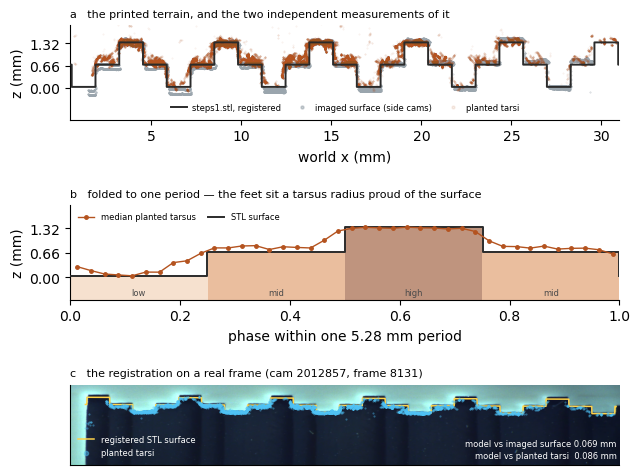


written: /home/user/3D_tracking_paper/stairs_v2/terrain_model.pdf

distance to the SURFACE (treads + risers) vs the vertical gap to a tread top
  median 0.091 mm against 0.108 mm; the surface is closer for 24% of leg-frames
  of the leg-frames within 0.30 mm of the surface, 22.9% are nearest a RISER face -- feet planted on the step edges, which a tread-only
  model has no height for and must score as airborne

hand-labelled terrain edges (2026_09_07_13_01_34)
  yaw -0.185 +- 0.216 deg, roll -0.031 +- 0.246 deg -- square to world x, as the alignment assumed
  phase: labelled 0.593 mm vs silhouette TERRAIN_X0 0.584 mm (9 um apart)
  period: labelled 5.2425 vs fitted 5.2779 mm
  tread heights: [-0.079  0.631  1.298  0.674] mm  (the parametric model has [0.027 0.687 1.347 0.687])
  per-leg claw offset (median distance while planted, mm): L1 0.083  R1 0.082  L2 0.047  R2 0.043  L3 0.141  R3 0.120
  planted-foot distance to the surface: labelled+offset p50 0.042, p90 0.130 mm   (CAD surface

In [12]:
# ---- The terrain, from the CAD model that was printed ----
import re, struct, shutil, subprocess
import imageio.v3 as iio
from skimage.filters import threshold_otsu

STL_PATH   = Path('/home/user/red_data/steps1.stl')
RECORDING  = Path('/mnt/flystateofmind/stairs_videos/2026_01_12_14_07_16')
CALIB_DIR  = RECORDING / 'calibration'
SIDE_CAMS  = ['2012857', '2012861']   # the two pure side views: u ~ 8.1x, v ~ +-8.0z
REG_FRAMES = [8131, 20000, 200000, 400000]
# extracted video frames are a cache for the silhouette registration, not figure
# output: kept out of OUTPUT_DIR so the figure directory holds only figures
TERRAIN_DIR = Path.home() / '.cache' / 'stairs_terrain_frames'
TERRAIN_DIR.mkdir(parents=True, exist_ok=True)

RAW_MM  = 0.01319465 * SCALE     # raw DLT unit -> mm, from alignment_info
STL_MM  = RAW_MM * 10.0          # 1 STL unit = 10 raw DLT units

# ── the STL profile ───────────────────────────────────────────────────────────
def read_stl_treads(path):
    """Upward-facing faces of a binary STL -> sorted (z0, z1, height) tread list."""
    raw = path.read_bytes()
    n   = struct.unpack('<I', raw[80:84])[0]
    rec = np.frombuffer(raw, count=n, offset=84,
                        dtype=np.dtype([('n', '<3f4'), ('v', '<3,3f4'), ('a', '<u2')]))
    V, N = rec['v'].reshape(-1, 3, 3).astype(float), rec['n'].astype(float)
    tre = [(t[:, 2].min(), t[:, 2].max(), t[:, 1].mean()) for t in V[N[:, 1] > 0.9]]
    walls = [t for t in tre if t[2] >= 10.0]        # the 11.353-high end walls
    return np.array(sorted(t for t in tre if t[2] < 10.0)), walls

TREADS, _WALLS = read_stl_treads(STL_PATH)
_LVL_Y  = np.unique(np.round(TREADS[:, 2], 3))
_LVL_OF = {y: i for i, y in enumerate(_LVL_Y)}
CAD_PERIOD, CAD_STEP = 4.0, float(np.diff(_LVL_Y).mean())
QSEQ = np.zeros(4, int)                             # level index at each quarter of a period
for _a, _b, _y in TREADS:
    QSEQ[int(round((_a + 37.0) % CAD_PERIOD))] = _LVL_OF[round(_y, 3)]

TERRAIN_PERIOD_MM = CAD_PERIOD * STL_MM
TERRAIN_STEP_MM   = CAD_STEP   * STL_MM
TREAD_MM          = 1.0        * STL_MM
print(f'steps1.stl: {len(TREADS)} treads, {len(_LVL_Y)} levels, '
      f'{(TREADS[:,1].max()-TREADS[:,0].min())/CAD_PERIOD:.0f} periods')
print(f'  level sequence within a period : {list(QSEQ)}   (0 = low, 2 = high)')
print(f'  period {TERRAIN_PERIOD_MM:.4f} mm | step {TERRAIN_STEP_MM:.4f} mm | '
      f'tread {TREAD_MM:.4f} mm   (1 STL unit = {STL_MM:.4f} mm)')

# ── camera helpers ────────────────────────────────────────────────────────────
def load_affine_cam(cam):
    """Rows 0,1 of the 3x4 projection matrix. Last row is [0,0,0,1] for every camera here."""
    txt  = (CALIB_DIR / f'Cam{cam}.yaml').read_text()
    nums = [float(v) for v in re.findall(r'-?\d+\.?\d*e?-?\d*', txt.split('data:')[1])]
    return np.array(nums[:8]).reshape(2, 4)

def project_world_mm(P, xyz_mm):
    """World mm -> pixels, through the affine camera."""
    raw = np.asarray(xyz_mm, float) / RAW_MM
    return (P @ np.c_[raw, np.ones(len(raw))].T)

def grab_frame(cam, frame):
    png = TERRAIN_DIR / f'cam{cam}_f{frame}.png'
    if not png.exists():
        exe = shutil.which('ffmpeg') or '/home/user/nvidia/ffmpeg/build/bin/ffmpeg'
        subprocess.run([exe, '-v', 'error', '-y', '-ss', f'{frame/FPS:.6f}',
                        '-i', str(RECORDING / f'Cam{cam}.mp4'), '-frames:v', '1', str(png)],
                       check=True)
    return png

def terrain_surface_from_image(cam, png):
    """Top edge of the terrain in a side view -> world (x_mm, z_mm).

    Polarity differs between the two side cameras -- 2012857 is BACKLIT (terrain dark on a
    bright field) and 2012861 is FRONT-LIT (white steps on black) -- so the terrain class is
    taken to be whichever Otsu class fills the bottom of the frame rather than a fixed sign.
    In both views the terrain occupies the lower part of the image and its surface is the
    topmost terrain pixel per column; the sign of P[1,2] carries the world-z direction.
    """
    P = load_affine_cam(cam)
    g = iio.imread(png)
    g = g[..., :3].mean(-1) if g.ndim == 3 else g * 1.0
    terr = g > threshold_otsu(g)
    if terr[-3:, :].mean() < 0.5:
        terr = ~terr
    H, W = g.shape
    edge = np.full(W, np.nan)
    for u in range(W):
        i = np.flatnonzero(terr[:, u])
        if i.size:
            edge[u] = i[0]
    ok = np.isfinite(edge)
    u, v = np.flatnonzero(ok).astype(float), edge[ok]
    return (u - P[0, 3]) / P[0, 0] * RAW_MM, (v - P[1, 3]) / P[1, 2] * RAW_MM

# ── the terrain model, as functions of world x ────────────────────────────────
def terrain_phase(x_mm, x0=None):
    """Position within one period, in [0, 1)."""
    x0 = TERRAIN_X0 if x0 is None else x0
    return ((np.asarray(x_mm, float) - x0) % TERRAIN_PERIOD_MM) / TERRAIN_PERIOD_MM

def terrain_level(x_mm, x0=None):
    """Tread index 0 (low) / 1 (mid) / 2 (high) under world x."""
    return QSEQ[np.floor(terrain_phase(x_mm, x0) * 4.0).astype(int) % 4]

def terrain_z(x_mm, x0=None, z0=None):
    z0 = TERRAIN_Z0 if z0 is None else z0
    return z0 + TERRAIN_STEP_MM * terrain_level(x_mm, x0)

def terrain_edge_dist(x_mm, x0=None):
    """mm to the nearest tread boundary."""
    q = terrain_phase(x_mm, x0) * 4.0
    return np.minimum(q % 1.0, 1.0 - q % 1.0) * TREAD_MM

def terrain_clearance(x_mm, z_mm, slop=0.18):
    """Signed height above the nearest tread the foot could be over.

    Near a boundary a horizontal error of a few tens of um flips the predicted height by a
    whole step, so within `slop` of an edge BOTH adjacent treads are candidates and the
    closer one wins. Measured on this dataset: 35.4% of planted feet within 0.15 mm of an
    edge are assigned the wrong tread by a single-tread rule, against 1.7% further away.
    """
    x_mm = np.asarray(x_mm, float); z_mm = np.asarray(z_mm, float)
    q  = terrain_phase(x_mm) * 4.0
    qw = slop / TREAD_MM
    near_edge = np.minimum(q % 1.0, 1.0 - q % 1.0) <= qw
    best = None
    for off in (-1, 0, 1):
        cand = TERRAIN_Z0 + TERRAIN_STEP_MM * QSEQ[(np.floor(q).astype(int) + off) % 4]
        dz   = np.where((off == 0) | near_edge, z_mm - cand, np.inf)
        best = dz if best is None else np.where(np.abs(dz) < np.abs(best), dz, best)
    return best

def _register(x, z, grid=0.001):
    best = None
    for x0 in np.arange(0, TERRAIN_PERIOD_MM, grid):
        pred = TERRAIN_STEP_MM * QSEQ[np.floor(((x - x0) % TERRAIN_PERIOD_MM)
                                               / TERRAIN_PERIOD_MM * 4.0).astype(int) % 4]
        z0   = np.median(z - pred)
        res  = np.median(np.abs(z - pred - z0))
        if best is None or res < best[0]:
            best = (res, x0, z0)
    return best

_reg_rows, _sil = [], []
if RECORDING.exists():
    for _cam in SIDE_CAMS:
        for _fr in REG_FRAMES:
            _x, _z = terrain_surface_from_image(_cam, grab_frame(_cam, _fr))
            _k = (_x > 1.5) & (_x < 29.5) & (_z > -0.6) & (_z < 2.2)
            _r, _x0, _z0 = _register(_x[_k], _z[_k])
            _reg_rows.append((f'{_cam} f{_fr}', _x0, _z0, _r, int(_k.sum())))
            _sil.append((_x[_k], _z[_k]))
else:
    print(f'WARNING: {RECORDING} not mounted -- registering from the feet alone.')

# the feet, as an independent check: a planted tarsus must lie ON the surface
_pf = []
for _b in bout_keys:
    _X = np.asarray(bout_dict[_b]['xpos'], float) * SCALE
    for _l in LEGS:
        _c  = _X[:, names_xpos.index(f'claw_{_l}')]
        _sp = np.r_[0, np.linalg.norm(np.diff(_c, axis=0), axis=1) * FPS]
        _pf.append(_c[_sp < STANCE_SPEED_MM_S])
FOOT_CLOUD = np.concatenate(_pf)
_rf, _x0f, _z0f = _register(FOOT_CLOUD[:, 0], FOOT_CLOUD[:, 2])

if _reg_rows:
    TERRAIN_X0 = float(np.mean([r[1] for r in _reg_rows]))
    TERRAIN_Z0 = float(np.mean([r[2] for r in _reg_rows]))
    _src = 'silhouette'
else:
    TERRAIN_X0, TERRAIN_Z0, _src = _x0f, _z0f, 'planted feet'

print(f'\nregistration ({_src}); the step height is fixed at the STL value, only x0 and z0 fit')
print(f'{"source":>18}{"x0 (mm)":>10}{"z0 (mm)":>10}{"resid (mm)":>13}{"n":>9}')
for _n, _a, _b_, _r, _nn in _reg_rows:
    print(f'{_n:>18}{_a:>10.3f}{_b_:>10.3f}{_r:>13.4f}{_nn:>9,}')
print(f'{"planted feet":>18}{_x0f:>10.3f}{_z0f:>10.3f}{_rf:>13.4f}{len(FOOT_CLOUD):>9,}')
if _reg_rows:
    print(f'  adopted  x0 = {TERRAIN_X0:.3f} +- {np.std([r[1] for r in _reg_rows]):.3f} mm, '
          f'z0 = {TERRAIN_Z0:.3f} +- {np.std([r[2] for r in _reg_rows]):.3f} mm')
    print(f'  the feet land {abs(_x0f-TERRAIN_X0):.3f} mm from the imaged surface '
          f'({abs(_x0f-TERRAIN_X0)/TERRAIN_PERIOD_MM*100:.1f}% of a period) -- an independent'
          f' check,\n  since nothing about the silhouette fit involves the tracked animal.')

# ── how much better is this than the rolling local floor it replaces? ─────────
_w = int(round(LOCAL_FLOOR_MS / 1000 * FPS))
_lf_err = []
for _l in LEGS:
    for _b, _g in df_valid.groupby('bout_id', sort=False):
        _z  = _g[f'{_l}_z_world_mm'].values.astype(float)
        _tx = terrain_z(_g[f'{_l}_x_world_mm'].values.astype(float))
        _lf = (pd.Series(_z).rolling(_w, center=True, min_periods=max(5, _w // 4))
               .quantile(LOCAL_FLOOR_PCT / 100).values)
        _lf_err.append(_lf - _tx)
_lf_err = np.concatenate(_lf_err); _lf_err = _lf_err[np.isfinite(_lf_err)]
print(f'\nthe rolling local floor ({LOCAL_FLOOR_MS:.0f} ms, {LOCAL_FLOOR_PCT:.0f}th pct) '
      f'against the true surface')
print(f'  RMS error {np.sqrt(np.mean(_lf_err**2)):.3f} mm, against a step of '
      f'{TERRAIN_STEP_MM:.3f} mm')
print(f'  |error| > half a step: {np.mean(np.abs(_lf_err) > TERRAIN_STEP_MM/2)*100:.1f}% of '
      f'leg-frames -- i.e. the rolling floor puts the foot on the')
print(f'  wrong tread about a third of the time. Every height-based rule built on it '
      f'inherits that.')

# ── per-frame terrain columns ─────────────────────────────────────────────────
def add_terrain_columns(d):
    """Terrain height, clearance, tread level and edge distance under every foot."""
    for l in LEGS:
        x = d[f'{l}_x_world_mm'].values.astype(float)
        z = d[f'{l}_z_world_mm'].values.astype(float)
        d[f'{l}_terrain_z_mm']  = terrain_z(x)
        d[f'{l}_clearance_mm']  = terrain_clearance(x, z)
        d[f'{l}_tread_level']   = terrain_level(x)
        d[f'{l}_edge_dist_mm']  = terrain_edge_dist(x)
    d['thorax_terrain_phase'] = terrain_phase(d['thorax_x_mm'].values.astype(float))
    d['thorax_terrain_z_mm']  = terrain_z(d['thorax_x_mm'].values.astype(float))
    return d

df_valid = add_terrain_columns(df_valid)
_cl = np.concatenate([df_valid[f'{l}_clearance_mm'].dropna().values for l in LEGS])
print(f'\nclearance above the true surface, all leg-frames: median {np.median(_cl):+.3f} mm, '
      f'p25 {np.percentile(_cl,25):+.3f}, p75 {np.percentile(_cl,75):+.3f}')

# colours used downstream by the 3-D scene
TREAD_CMAP  = ['#F0C9A8', '#D98A4E', '#8C3D14']   # ordered levels -> one hue, light to dark
STAIRS_C    = COND_COLORS['stairs'] if 'COND_COLORS' in globals() else '#B4531F'
FLAT_C      = COND_COLORS['flat']   if 'COND_COLORS' in globals() else '#3B4A56'

# ---- the SURFACE, not just its tops: treads AND risers ----
def terrain_surface_dist(x_mm, z_mm, n=2):
    """Distance to the tread+riser profile, the height of the nearest point on it, and
    whether that point is on a riser. Searches n treads either side of x."""
    x = np.asarray(x_mm, float); z = np.asarray(z_mm, float)
    k0 = np.floor((x - TERRAIN_X0) / TREAD_MM).astype(int)
    best = np.full(x.shape, np.inf); sup = np.full(x.shape, np.nan)
    ris = np.zeros(x.shape, bool)
    for dk in range(-n, n + 1):
        k = k0 + dk
        e = TERRAIN_X0 + k * TREAD_MM
        zk = TERRAIN_Z0 + TERRAIN_STEP_MM * QSEQ[k % 4]
        d = np.hypot(np.maximum(np.maximum(e - x, x - (e + TREAD_MM)), 0.0), z - zk)
        take = d < best
        best, sup, ris = np.where(take, d, best), np.where(take, zk, sup), np.where(take, False, ris)
        zp = TERRAIN_Z0 + TERRAIN_STEP_MM * QSEQ[(k - 1) % 4]          # the riser at x = e
        lo, hi = np.minimum(zp, zk), np.maximum(zp, zk)
        d = np.hypot(x - e, z - np.clip(z, lo, hi))
        take = (d < best) & (hi > lo)
        best, sup, ris = np.where(take, d, best), np.where(take, np.clip(z, lo, hi), sup), np.where(take, True, ris)
    return best, sup, ris

for _l in LEGS:
    _sd, _sz, _sr = terrain_surface_dist(df_valid[f'{_l}_x_world_mm'].values.astype(float),
                                         df_valid[f'{_l}_z_world_mm'].values.astype(float))
    df_valid[f'{_l}_surf_dist_mm'] = _sd
    df_valid[f'{_l}_surf_z_mm']    = _sz     # the height the foot is supported at, riser included
    df_valid[f'{_l}_on_riser']     = _sr.astype(float)

_sd = np.concatenate([df_valid[f'{l}_surf_dist_mm'].values for l in LEGS])
_sr = np.concatenate([df_valid[f'{l}_on_riser'].values for l in LEGS]) > .5
_cl = np.abs(np.concatenate([df_valid[f'{l}_clearance_mm'].values for l in LEGS]))
print(f'\ndistance to the SURFACE (treads + risers) vs the vertical gap to a tread top')
print(f'  median {np.nanmedian(_sd):.3f} mm against {np.nanmedian(_cl):.3f} mm; the surface is '
      f'closer for {np.nanmean(_sd < _cl - 1e-9)*100:.0f}% of leg-frames')
print(f'  of the leg-frames within 0.30 mm of the surface, {_sr[_sd <= .30].mean()*100:.1f}% are '
      f'nearest a RISER face -- feet planted on the step edges, which a tread-only')
print(f'  model has no height for and must score as airborne')

# ---- the surface, MEASURED: hand-labelled tread edges ----
LABEL_CSV = Path('/mnt/flystateofmind/stairs_videos/2026_01_12_14_07_16/red_project/'
                 'calib stairs/labeled_data/2026_09_07_13_01_34/keypoints3d.csv')

_lab = pd.read_csv(LABEL_CSV, skiprows=2)
_LP = np.stack([_lab[[f'x{i}', f'y{i}', f'z{i}']].values for i in range(20)], 1)[0].reshape(10, 2, 3)
_ex = _LP[:, :, 0].mean(1) * STL_MM              # edge x, model mm
_ez = _LP[:, :, 2].mean(1) * STL_MM              # edge z, model mm
LABEL_LEVELS = np.array([np.mean(_ez[i:i + 2]) for i in range(0, 10, 2)])[:4]
LABEL_BOUNDS = (_ex[:8] - _ex[0]) * TERRAIN_PERIOD_MM / (_ex[8] - _ex[0])   # to the fitted period
LABEL_X0 = float(_ex[0])
_yaw = [np.degrees(np.arctan2(*(np.diff(e[np.argsort(e[:, 1])][:, [0, 1]], axis=0)[0])))
        for e in _LP]
_roll = [np.degrees(np.arctan2(*(np.diff(e[np.argsort(e[:, 1])][:, [2, 1]], axis=0)[0])))
         for e in _LP]
print(f'\nhand-labelled terrain edges ({LABEL_CSV.parent.name})')
print(f'  yaw {np.mean(_yaw):+.3f} +- {np.std(_yaw):.3f} deg, roll {np.mean(_roll):+.3f} '
      f'+- {np.std(_roll):.3f} deg -- square to world x, as the alignment assumed')
print(f'  phase: labelled {LABEL_X0:.3f} mm vs silhouette TERRAIN_X0 {TERRAIN_X0:.3f} mm '
      f'({abs(LABEL_X0 - TERRAIN_X0) * 1000:.0f} um apart)')
print(f'  period: labelled {_ex[8] - _ex[0]:.4f} vs fitted {TERRAIN_PERIOD_MM:.4f} mm')
print(f'  tread heights: {np.round(LABEL_LEVELS, 3)} mm  (the parametric model has '
      f'{np.round([TERRAIN_Z0 + TERRAIN_STEP_MM * q for q in QSEQ[:4]], 3)})')

def terrain_surface_dist_labelled(x_mm, z_mm):
    """Distance to the surface built from the labelled edges: four measured treads + risers."""
    x = np.asarray(x_mm, float); z = np.asarray(z_mm, float)
    best = np.full(x.shape, np.inf)
    for kk in (-1, 0, 1):
        q = (x - LABEL_X0) % TERRAIN_PERIOD_MM + kk * TERRAIN_PERIOD_MM
        for i in range(4):
            x0, x1 = LABEL_BOUNDS[2 * i], LABEL_BOUNDS[2 * i + 1]
            best = np.minimum(best, np.hypot(np.maximum(np.maximum(x0 - q, q - x1), 0.0),
                                             z - LABEL_LEVELS[i]))
        for i in range(4):                                    # the riser between tread i, i+1
            xr = ((LABEL_BOUNDS[2 * i + 1] + LABEL_BOUNDS[(2 * i + 2) % 8]) / 2 if i < 3 else
                  LABEL_BOUNDS[7] + (TERRAIN_PERIOD_MM - LABEL_BOUNDS[7]) / 2)
            lo, hi = sorted((LABEL_LEVELS[i], LABEL_LEVELS[(i + 1) % 4]))
            best = np.minimum(best, np.hypot(q - xr, z - np.clip(z, lo, hi)))
    return best

# ---- per-leg claw offset ----
CLAW_OFFSET_MM = {}
for _l in LEGS:
    _d = terrain_surface_dist_labelled(df_valid[f'{_l}_x_world_mm'].values.astype(float),
                                       df_valid[f'{_l}_z_world_mm'].values.astype(float))
    _planted = df_valid[f'{_l}_tipspeed'].values < 6.0
    CLAW_OFFSET_MM[_l] = float(np.nanmedian(_d[_planted]))
    df_valid[f'{_l}_surf_dist_cad_mm'] = df_valid[f'{_l}_surf_dist_mm']   # keep the CAD one
    df_valid[f'{_l}_surf_dist_mm'] = np.abs(_d - CLAW_OFFSET_MM[_l])      # the one rules use
print(f'  per-leg claw offset (median distance while planted, mm): '
      + '  '.join(f'{LEG_LABELS[l]} {CLAW_OFFSET_MM[l]:.3f}' for l in LEGS))
_dd = np.concatenate([df_valid[f'{l}_surf_dist_mm'].values[df_valid[f'{l}_tipspeed'].values < 6]
                      for l in LEGS])
_cc = np.concatenate([np.abs(df_valid[f'{l}_surf_dist_cad_mm'].values)[
    df_valid[f'{l}_tipspeed'].values < 6] for l in LEGS])
print(f'  planted-foot distance to the surface: labelled+offset p50 '
      f'{np.nanpercentile(_dd, 50):.3f}, p90 {np.nanpercentile(_dd, 90):.3f} mm'
      f'   (CAD surface: p50 {np.nanpercentile(_cc, 50):.3f}, p90 '
      f'{np.nanpercentile(_cc, 90):.3f})')


## 3-D scene helpers

rule                       duty  swings  med ms   no-lift  stance w/o  DS flags  curated
phase (as used above)      0.64     639      59     10.5%        4.4%       222      7/7
phase + terrain            0.62     518      64      0.0%        0.0%       225      7/7
speed (Output 2)           0.64     702      56     14.8%        4.3%       219      7/7
speed + terrain            0.63     532      62      0.0%        0.0%       224      7/7

frame-level agreement between the phase rule and the speed rule
 leg    before    after
  L1      100%      99%
  R1      100%      99%
  L2      100%     100%
  R2      100%     100%
  L3      100%     100%
  R3      100%      99%
 all      100%     100%
  swing count 639 vs 702 before correction (9% apart), 518 vs 532 after (3% apart).
  the correction never references the other rule, so the convergence is not built in.
  all 7/7 curated double swings survive the correction.

  `{leg}_stance_terr` (= phase + terrain) is the binary the cells below

/tmp/ipykernel_45870/3896228819.py:363: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, .94])


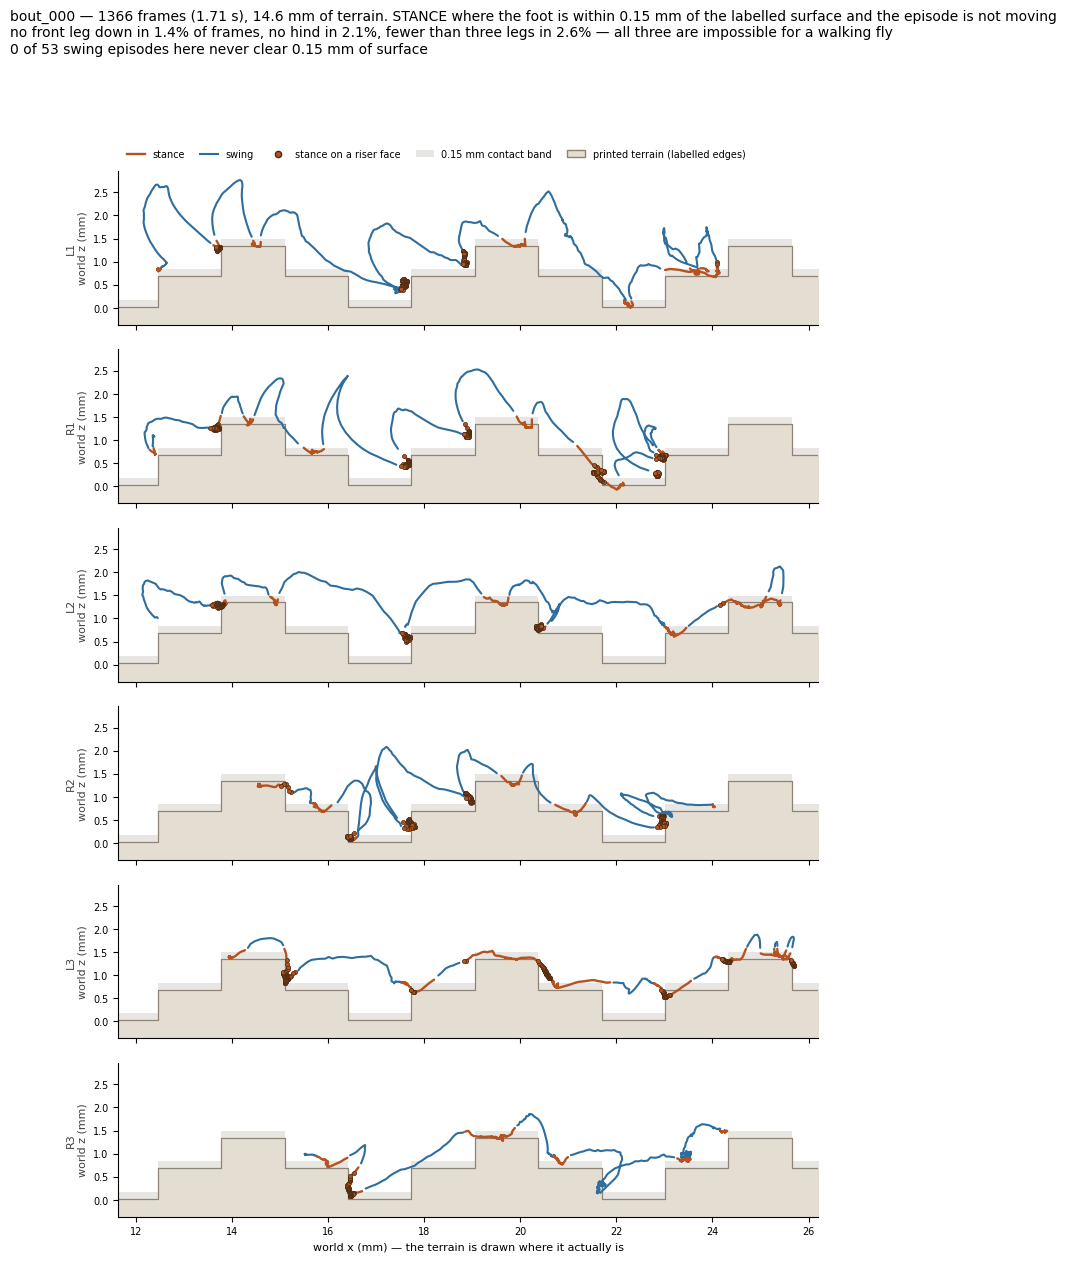

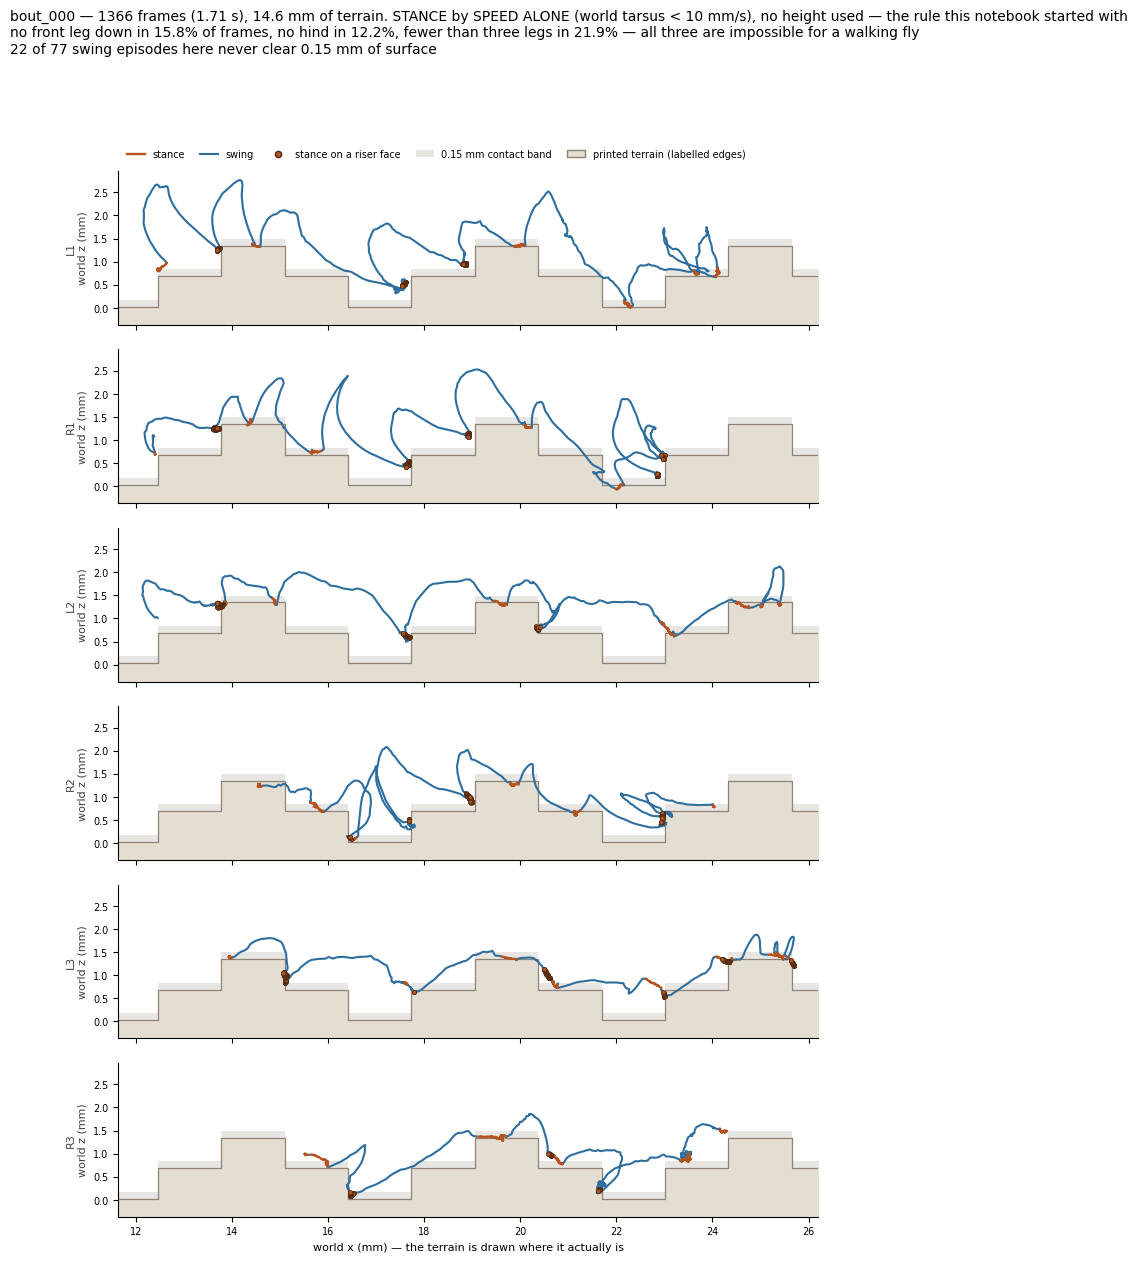

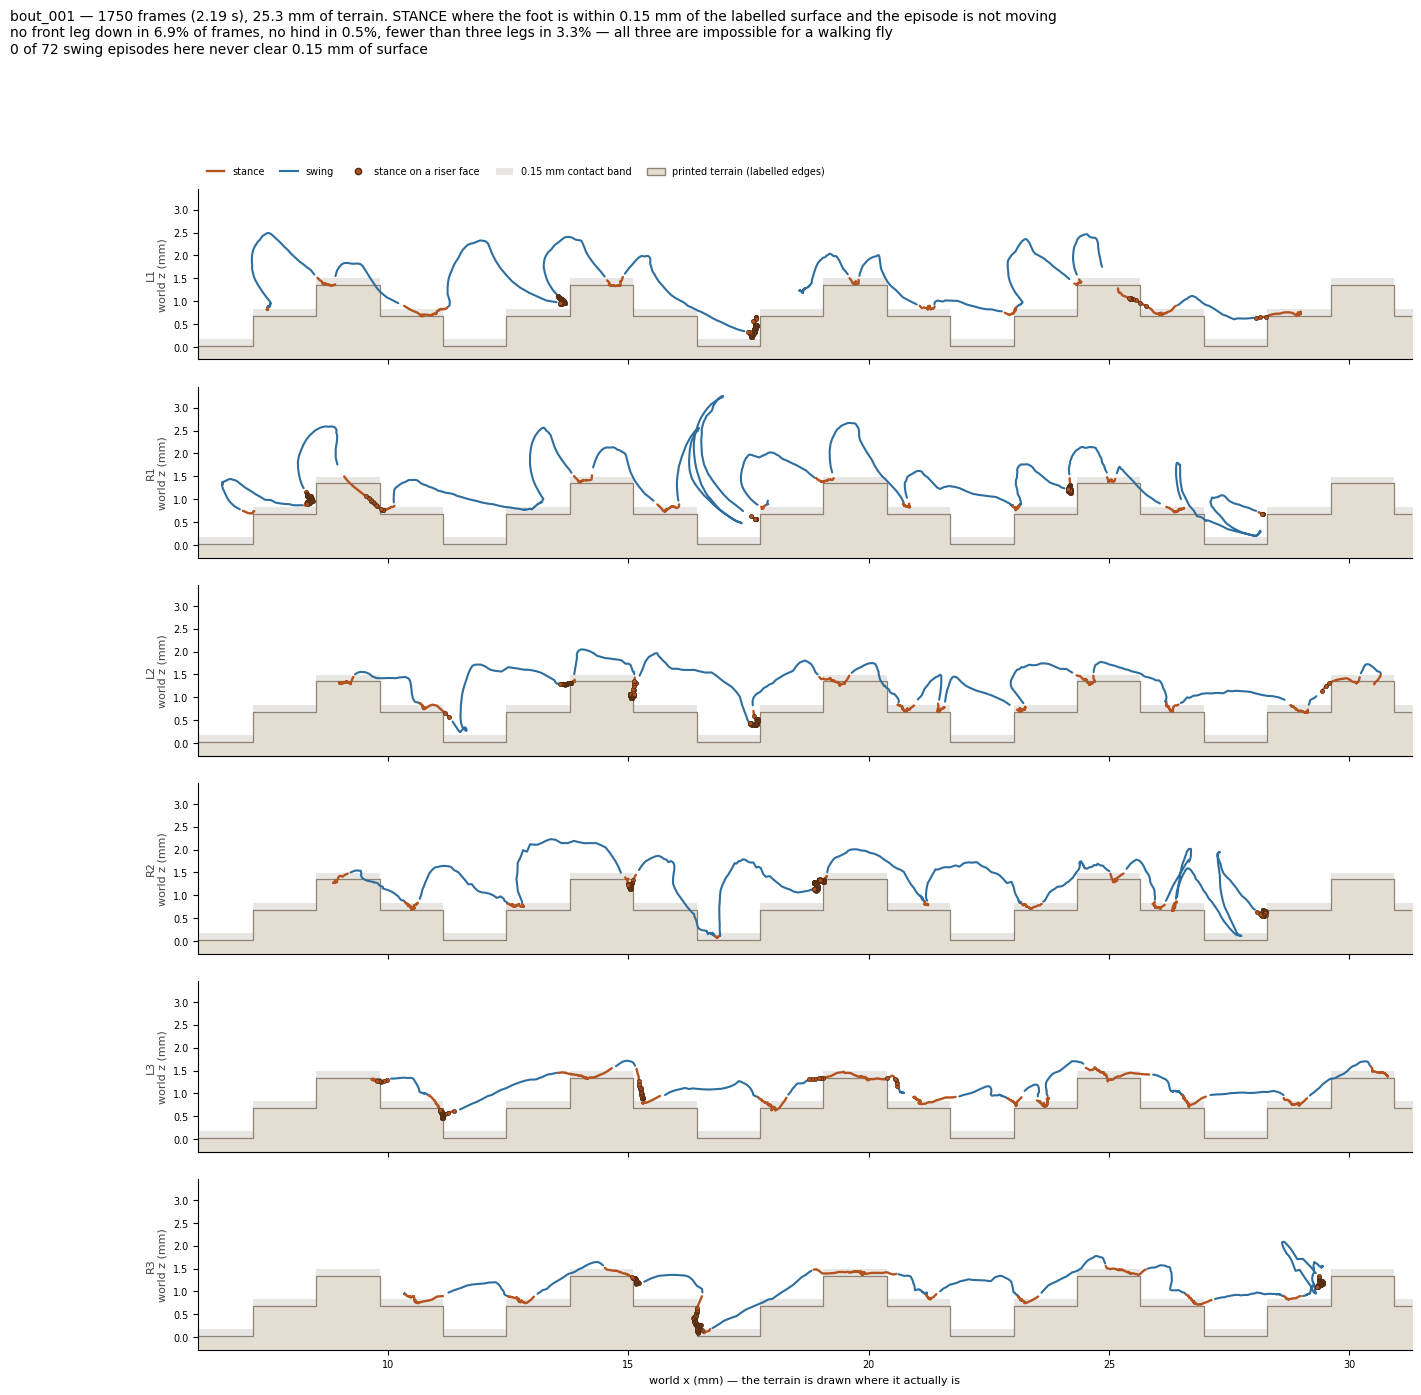

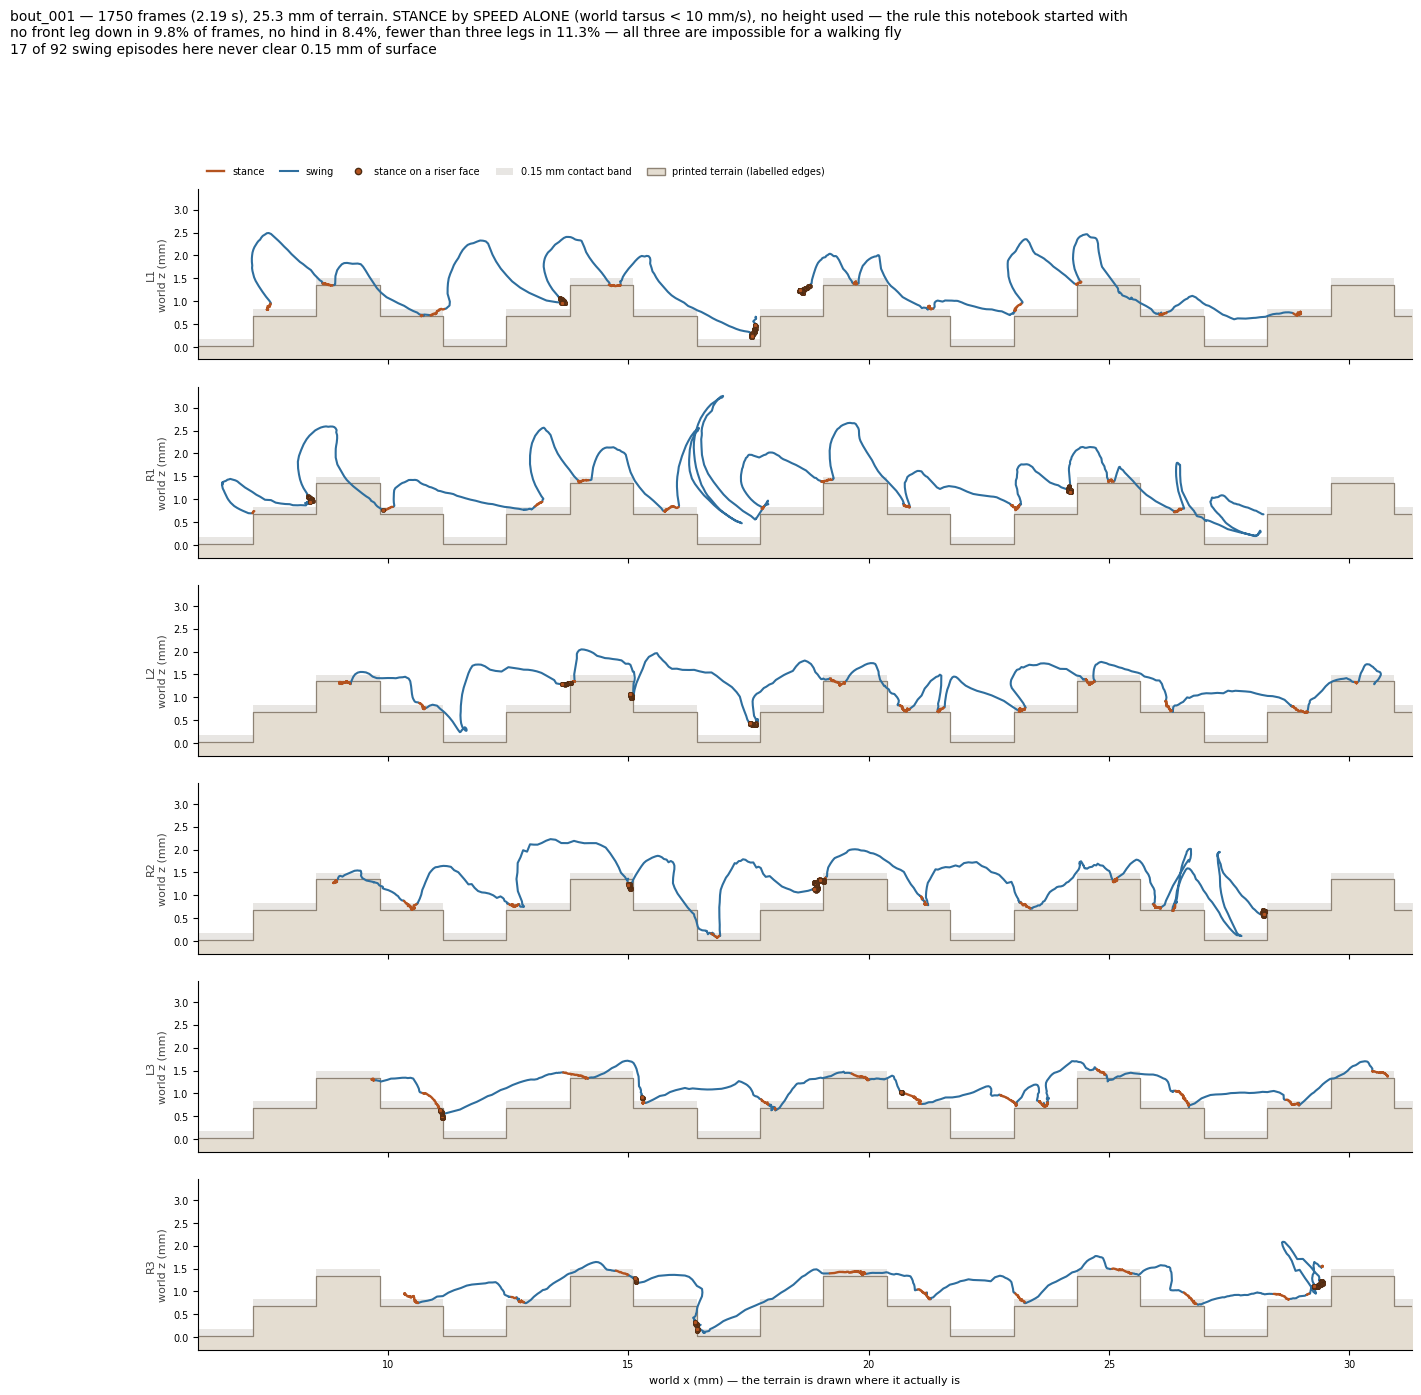

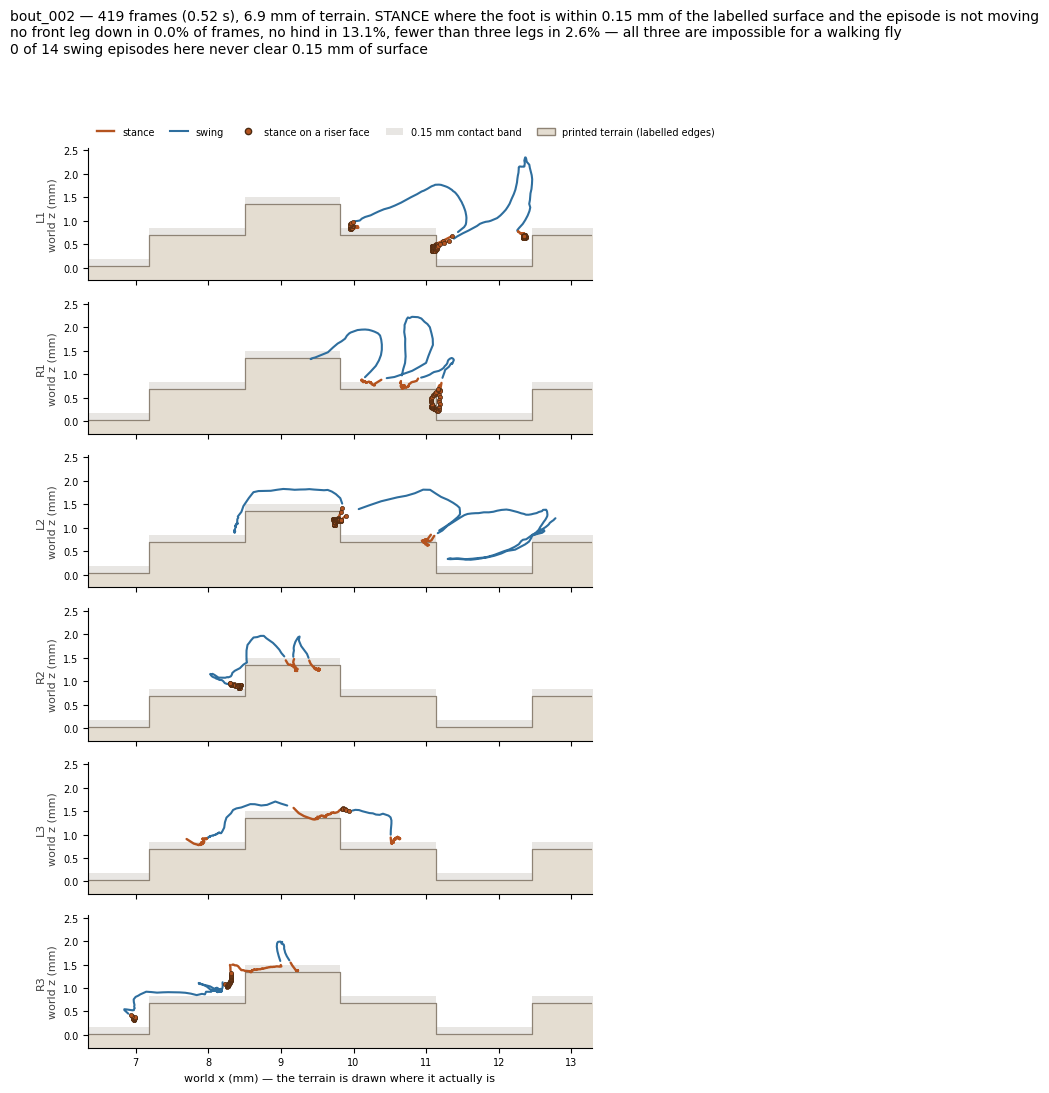

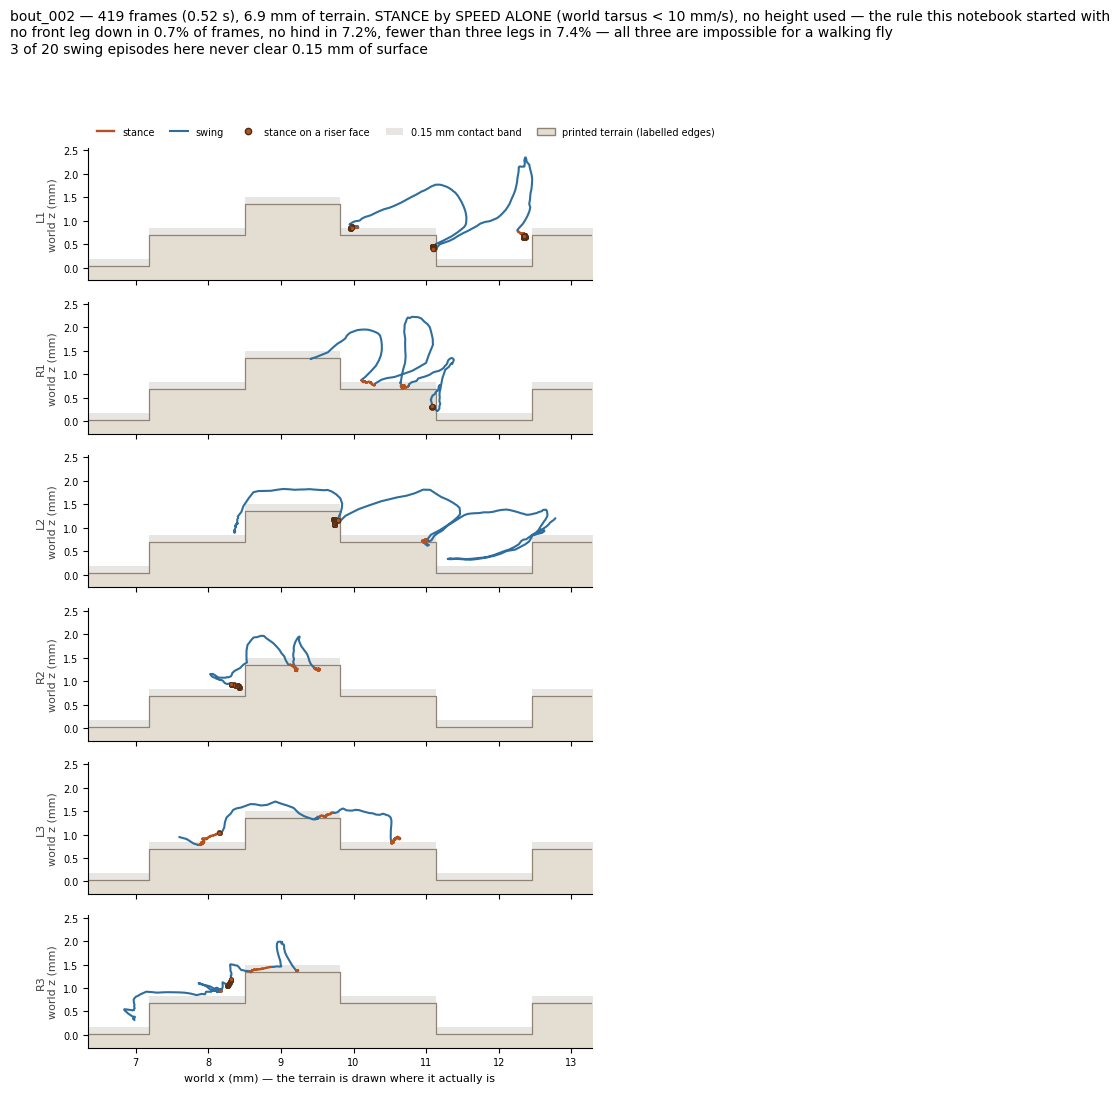


wrote 34 figures to /home/user/3D_tracking_paper/stairs_v2/bout_traces/*_stance_{surface,speedonly}.png
read them as a pair: the speed rule paints blue over feet that are sitting on a tread,
because a planted tarsus is only stationary while the body above it is not rotating.


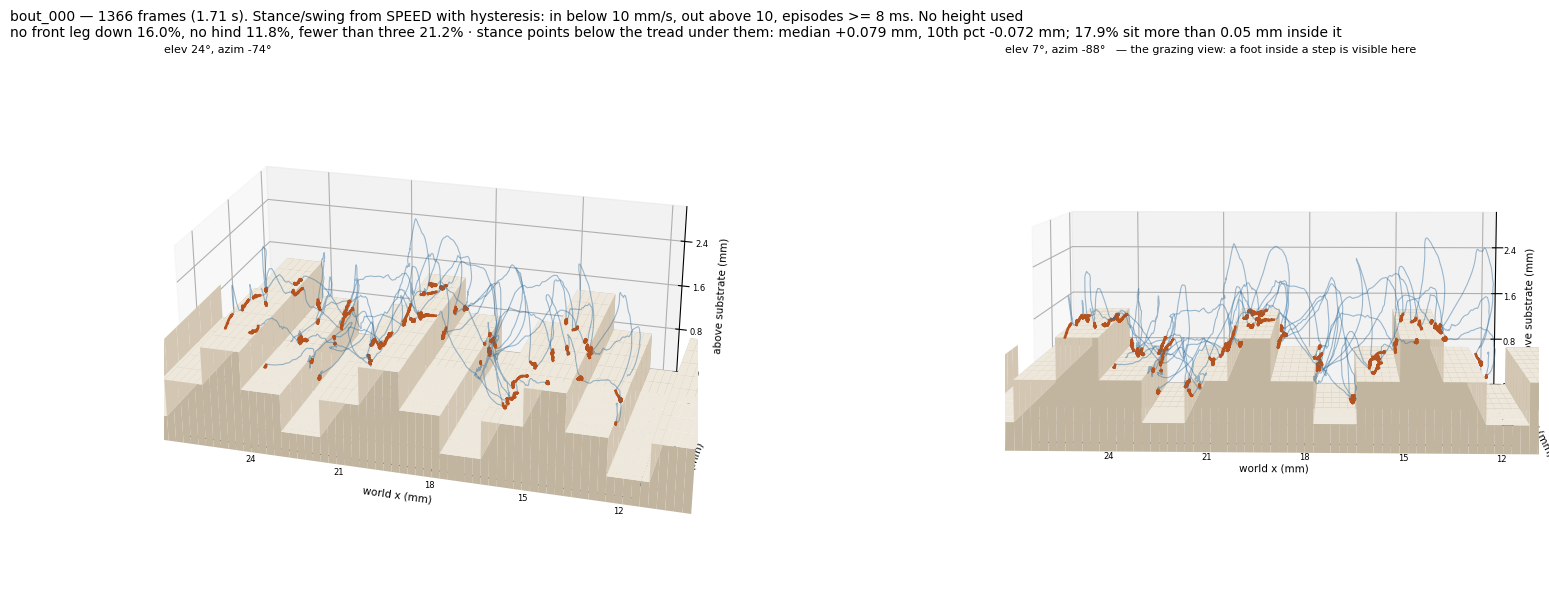

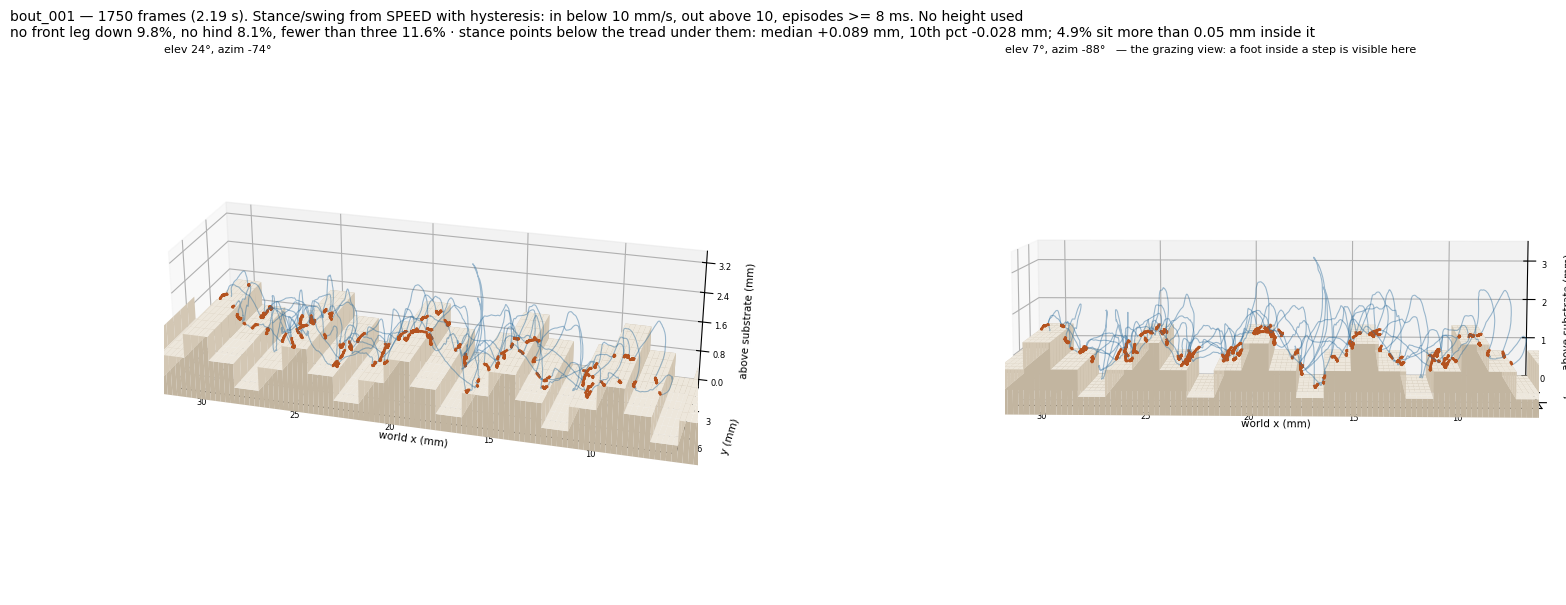


wrote 17 figures to /home/user/3D_tracking_paper/stairs_v2/bout_traces/*_walk_3d.png

3D control pair: bout_001 has 15 step cycles; flat bout bout_0736 has 12, cropped to its first 12


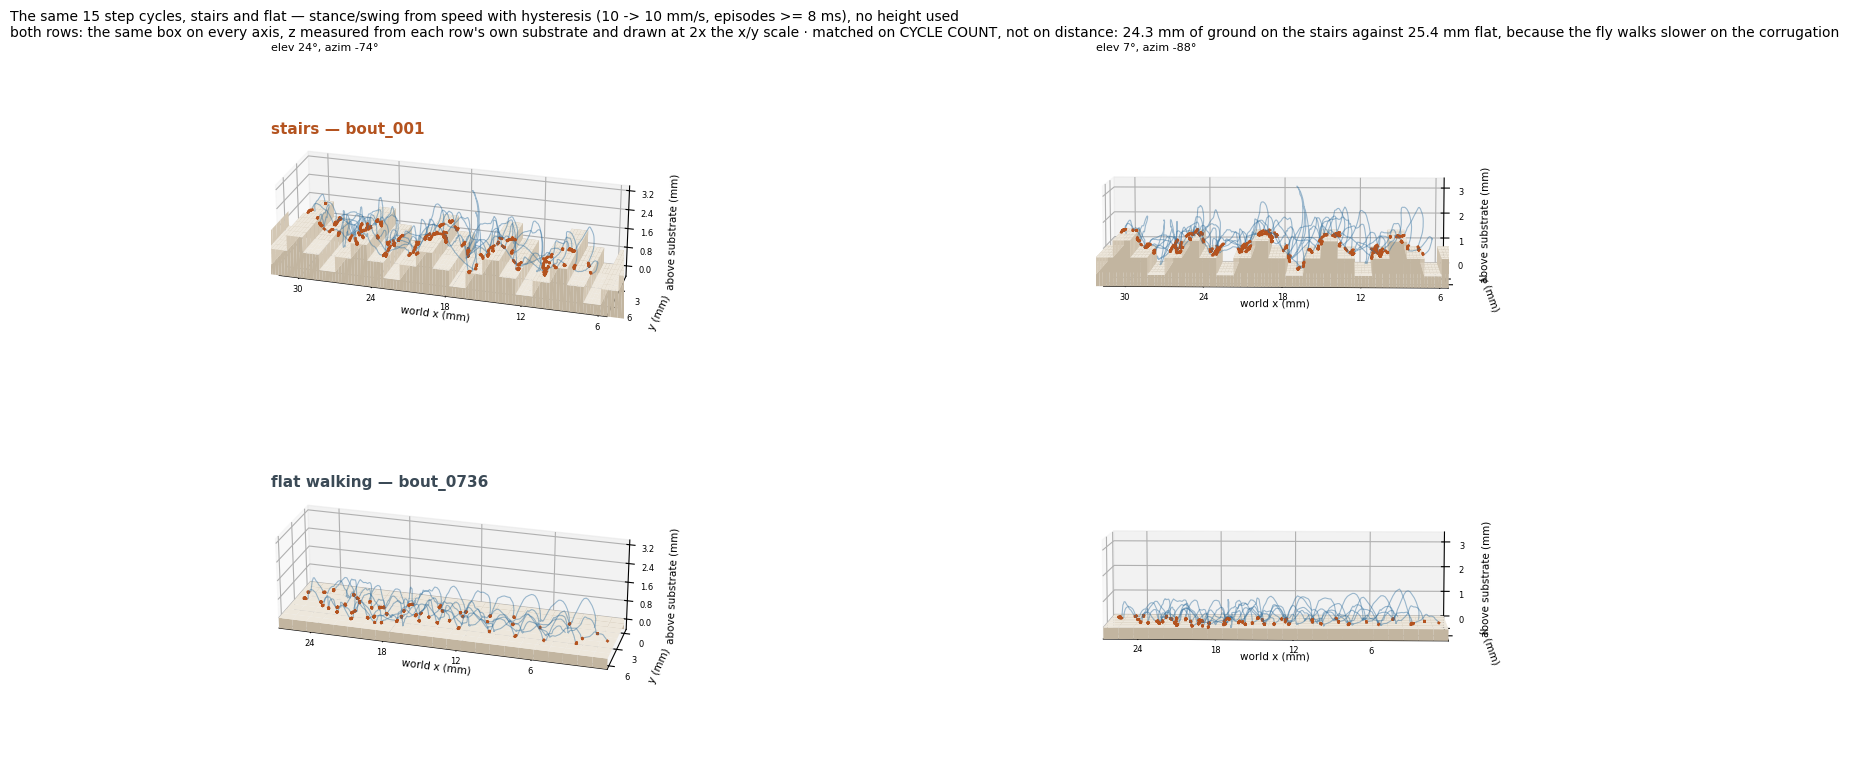

wrote /home/user/3D_tracking_paper/stairs_v2/walk_3d_bout_001_vs_flat_*.png


In [13]:
# ---- 3-D scene helpers: terrain and flat meshes, bout trimming, flat matching ----
CONTACT_BAND_MM = 0.20    # within this of a tread surface = touching it
LIFT_MIN_MM     = 0.15    # a real swing clears the surface by at least this
CORRECT_PASSES  = 3
def _episodes(mask):
    m = np.asarray(mask, bool).astype(np.int8)
    d = np.diff(np.r_[0, m, 0])
    return list(zip(np.flatnonzero(d == 1), np.flatnonzero(d == -1)))
def terrain_correct_contact(contact, clearance, passes=CORRECT_PASSES):
    """Flip whole episodes that the surface says cannot be what they are labelled."""
    ct = np.asarray(contact, bool).copy()
    cl = np.asarray(clearance, float)
    for _ in range(passes):
        changed = False
        for a, b in _episodes(~ct):                       # a swing that never lifted
            seg = cl[a:b]
            if np.isfinite(seg).any() and np.nanmax(seg) < LIFT_MIN_MM:
                ct[a:b] = True; changed = True
        for a, b in _episodes(ct):                        # a stance that never landed
            seg = cl[a:b]
            if np.isfinite(seg).any() and np.nanmin(np.abs(seg)) > CONTACT_BAND_MM:
                ct[a:b] = False; changed = True
        if not changed:
            break
    return ct
_BASE = {'phase': lambda g, l: np.nan_to_num(g[f'{l}_swing_stance'].values, nan=0) > .5,
         'speed': lambda g, l: np.nan_to_num(g[f'{l}_planted'].values,      nan=0) > .5}
for _nm, _get in _BASE.items():
    for _l in LEGS:
        _out = np.zeros(len(df_valid), bool)
        for _b, _g in df_valid.groupby('bout_id', sort=False):
            _out[_g.index] = terrain_correct_contact(_get(_g, _l),
                                                     _g[f'{_l}_clearance_mm'].values)
        df_valid[f'{_l}_stance_{_nm}_terr'] = _out.astype(float)
for _l in LEGS:
    df_valid[f'{_l}_stance_terr'] = df_valid[f'{_l}_stance_hyst']
DS_CURATED = [('bout_001', 'T2_right',  23085), ('bout_001', 'T1_right',  24203),
              ('bout_006', 'T3_left',  112330), ('bout_008', 'T1_right', 190488),
              ('bout_008', 'T2_left',  190733), ('bout_011', 'T1_left',  323545),
              ('bout_011', 'T2_right', 323918)]
def _rule_stats(col):
    n_sw = n_nolift = n_st = n_noc = 0
    duty, swms, ds = [], [], []
    for l in LEGS:
        for b, g in df_valid.groupby('bout_id', sort=False):
            ct = np.nan_to_num(g[col(l)].values, nan=0) > .5
            cl = g[f'{l}_clearance_mm'].values.astype(float)
            af = g['abs_frame'].values
            duty.append(ct.mean())
            for a, b2 in _episodes(~ct):
                if b2 - a < 3:
                    continue
                n_sw += 1; swms.append((b2 - a) / FPS * 1000)
                seg = cl[a:b2]
                if np.isfinite(seg).any() and np.nanmax(seg) < LIFT_MIN_MM:
                    n_nolift += 1
                pk, _ = find_peaks(seg, height=LIFT_MIN_MM, prominence=0.12)
                if len(pk) >= 2 and np.nanmin(seg[pk[0]:pk[-1]]) < CONTACT_BAND_MM:
                    ds.append((b, l, int(af[a])))
            for a, b2 in _episodes(ct):
                n_st += 1
                seg = cl[a:b2]
                if ((b2 - a) / FPS * 1000 >= MIN_STANCE_MS and np.isfinite(seg).any()
                        and np.nanmin(np.abs(seg)) > CONTACT_BAND_MM):
                    n_noc += 1
    hits = sum(any(t[0] == e[0] and t[1] == e[1] and abs(t[2] - e[2]) < 400 for e in ds)
               for t in DS_CURATED)
    return dict(duty=np.mean(duty), nsw=n_sw, nolift=n_nolift / max(n_sw, 1) * 100,
                noc=n_noc / max(n_st, 1) * 100, swms=np.median(swms),
                nds=len(ds), hits=hits)
_RULES = {'phase (as used above)':  lambda l: f'{l}_swing_stance',
          'phase + terrain':        lambda l: f'{l}_stance_phase_terr',
          'speed (Output 2)':       lambda l: f'{l}_planted',
          'speed + terrain':        lambda l: f'{l}_stance_speed_terr'}
_S = {k: _rule_stats(v) for k, v in _RULES.items()}
for k, s in _S.items():
    print(f'{k:<24}{s["duty"]:>7.2f}{s["nsw"]:>8}{s["swms"]:>8.0f}{s["nolift"]:>9.1f}%'
          f'{s["noc"]:>11.1f}%{s["nds"]:>10}{s["hits"]:>7}/7')
_ab, _aa = [], []
for _l in LEGS:
    _p  = np.nan_to_num(df_valid[f'{_l}_swing_stance'].values, nan=0) > .5
    _sp = np.nan_to_num(df_valid[f'{_l}_planted'].values,      nan=0) > .5
    _pt = df_valid[f'{_l}_stance_phase_terr'].values > .5
    _st = df_valid[f'{_l}_stance_speed_terr'].values > .5
    _ab.append((_p == _sp).mean()); _aa.append((_pt == _st).mean())
    print(f'{LEG_LABELS[_l]:>4}{_ab[-1]*100:>9.0f}%{_aa[-1]*100:>8.0f}%')
SURF_CONTACT_MM     = 0.15   # JI 2026-09-07: 0.25 mm is too wide to call a foot planted
SURF_SPLIT_MM_S     = 16.0
SURF_MIN_STANCE_MS  = 8.0
def surface_contact(dist, spd, contact=SURF_CONTACT_MM, split=SURF_SPLIT_MM_S,
                    min_ms=SURF_MIN_STANCE_MS):
    st = np.asarray(dist, float) <= contact
    for a, b in _episodes(st):
        if np.nanmedian(spd[a:b]) > split:
            st[a:b] = False
    for a, b in _episodes(~st):
        if np.nanmax(dist[a:b]) < LIFT_MIN_MM:
            st[a:b] = True
    for a, b in _episodes(st):
        if (b - a) / FPS * 1000 < min_ms:
            st[a:b] = False
    return st
for _l in LEGS:
    _out = np.zeros(len(df_valid), bool)
    for _b, _g in df_valid.groupby('bout_id', sort=False):
        _out[_g.index] = surface_contact(_g[f'{_l}_surf_dist_mm'].values.astype(float),
                                         _g[f'{_l}_tipspeed'].values.astype(float))
    df_valid[f'{_l}_stance_surf'] = _out.astype(float)
def _impossible(col):
    M = np.stack([np.nan_to_num(df_valid[col(l)].values, nan=0) > .5 for l in LEGS], 1)
    fi = [LEGS.index(l) for l in ('T1_left', 'T1_right')]
    hi = [LEGS.index(l) for l in ('T3_left', 'T3_right')]
    sw, lift, st_, touch = [], 0, 0, 0
    for _b, _g in df_valid.groupby('bout_id', sort=False):
        for l in LEGS:
            ct = np.nan_to_num(_g[col(l)].values, nan=0) > .5
            ds = _g[f'{l}_surf_dist_mm'].values.astype(float)
            for a, b in _episodes(~ct):
                if b - a >= 3:
                    sw.append((b - a) / FPS * 1000); lift += np.nanmax(ds[a:b]) >= LIFT_MIN_MM
            for a, b in _episodes(ct):
                st_ += 1; touch += np.nanmin(ds[a:b]) <= CONTACT_BAND_MM
    return dict(duty=M.mean(), nof=(M[:, fi].sum(1) == 0).mean() * 100,
                noh=(M[:, hi].sum(1) == 0).mean() * 100, n3=(M.sum(1) < 3).mean() * 100,
                swms=np.median(sw), lift=lift / max(len(sw), 1) * 100,
                touch=touch / max(st_, 1) * 100)
for _nm, _c in (('phase + terrain (in use)', lambda l: f'{l}_stance_terr'),
                ('surface + speed (new)', lambda l: f'{l}_stance_surf')):
    _s = _impossible(_c)
    print(f'{_nm:>26}{_s["duty"]:>7.2f}{_s["nof"]:>9.1f}%{_s["noh"]:>8.1f}%{_s["n3"]:>8.1f}%'
          f'{_s["swms"]:>10.1f}{_s["lift"]:>17.0f}%{_s["touch"]:>19.0f}%')
_ag = np.mean([np.mean((np.nan_to_num(df_valid[f'{l}_stance_terr'].values, nan=0) > .5) ==
                       (df_valid[f'{l}_stance_surf'].values > .5)) for l in LEGS])
FIG_TRIM_TAIL_CYCLES = {'bout_001': 1}
FIG_TRIM_REF_LEG = 'T1_left'
def _fig_trim(g, bout):
    """Drop the trailing step cycles a bout is excluded for, ending on a planted frame."""
    n = FIG_TRIM_TAIL_CYCLES.get(bout, 0)
    if not n or 'step_cycle_id' not in g:
        return g
    cyc = np.sort(g.step_cycle_id.dropna().unique())
    if len(cyc) <= n:
        return g
    g = g[g.step_cycle_id.isin(cyc[:-n])]
    st = np.nan_to_num(g[f'{FIG_TRIM_REF_LEG}_swing_stance'].values, nan=0) > .5
    last = np.flatnonzero(st)
    return g.iloc[:int(last[-1]) + 1] if len(last) else g
SURF_TRACE_X         = 'terrain'  # 'terrain' = world x, the staircase itself | 'time' = ms
SURF_TRACE_IN_PER_MM = 0.62       # inches per mm, applied to BOTH axes -> a true side view
SURF_TRACE_BOUTS     = 'all'      # 'all' | a list like ['bout_001', 'bout_002']
STANCE_HUE, SWING_HUE = '#B4531F', '#2E6E9E'
RISER_EDGE = '#4A2A12'
_snames = sorted(df_valid.bout_id.unique())
if isinstance(SURF_TRACE_BOUTS, list):
    _snames = [b for b in _snames if b in SURF_TRACE_BOUTS]
D3_ELEV_AZIM = [(24, -74), (7, -88)]   # -74 is the angle chosen in the colour trials
D3_PEN_MM = 0.05      # deeper than this below the tread top counts as inside the block
D3_TREAD_C, D3_RISER_C, D3_SIDE_C = '#EDE7DC', '#D3C7B4', '#C2B5A0'
D3_BASE_MM = 0.45     # how far below the lowest tread the block is drawn
D3_ZMAX_MM = 3.4
D3_TERRAIN_X_MM = (0.0, 6 * TERRAIN_PERIOD_MM)
def _terrain_mesh(x0, x1, y0, y1, n_y=9, eps=2e-4, z_off=0.0):
    """The corrugation as a meshed surface plus its two cut faces, ready for plot_surface.

    WHY A MESH AND NOT A FEW BIG QUADS. matplotlib sorts whole polygons by their mean depth,
    so a staircase built from a few dozen tread and riser faces is drawn in the wrong order
    from most angles -- treads punching through risers, the far wall in front of the near one,
    the "crazy" look. Small faces have a mean depth close to their true depth, so the sort is
    right almost everywhere.
    WHY EXPLICIT FACE COLOURS AND NO LIGHTING. matplotlib's shading takes a normal per face,
    and the riser faces are vertical: any light direction that keeps the treads readable turns
    the risers nearly black. Treads, risers and the cut sides get a flat colour each instead,
    which is also what a CAD drawing of this part would do.
    Returns (X, Y, Z, C) for the top surface and a list of (X, Y, Z, colour) skirts that close
    the block at the two y faces, so it reads as material rather than as a folded ribbon.
    """
    k = np.arange(int(np.floor((x0 - TERRAIN_X0) / TREAD_MM)) - 1,
                  int(np.ceil((x1 - TERRAIN_X0) / TREAD_MM)) + 2)
    xe = TERRAIN_X0 + k * TREAD_MM
    ze = TERRAIN_Z0 + TERRAIN_STEP_MM * QSEQ[k % 4]
    xs, zs = [], []
    for i in range(len(k) - 1):
        a, b, z = xe[i], xe[i + 1], ze[i]
        m = np.linspace(a + eps, b - eps, 6)                  # the tread top
        xs += list(m); zs += [z] * len(m)
        xs += [b, b]; zs += [z, ze[i + 1]]                    # the riser, a vertical wall
    X1 = np.asarray(xs); Z1 = np.asarray(zs) - z_off
    Y = np.linspace(y0, y1, n_y)
    XX, YY = np.meshgrid(X1, Y)
    ZZ = np.tile(Z1, (n_y, 1))
    vertical = np.abs(np.diff(X1)) < 1e-6                     # which columns are risers
    C = np.where(vertical[None, :], D3_RISER_C, D3_TREAD_C)
    C = np.repeat(C, n_y, axis=0)[:n_y - 1]
    skirts = []
    for yy in (y0, y1):
        skirts.append((np.tile(X1, (2, 1)), np.full((2, len(X1)), yy),
                       np.vstack([np.full(len(X1), TERRAIN_Z0 - z_off - D3_BASE_MM), Z1])))
    return XX, YY, ZZ, C, skirts
D3_REF_BOUT = 'bout_001'
def _flat_mesh(x0, x1, y0, y1, z, n=24):
    """The control substrate: one plane, meshed like the corrugation so it sorts the same."""
    X = np.linspace(x0, x1, n)
    Y = np.linspace(y0, y1, 9)
    XX, YY = np.meshgrid(X, Y)
    ZZ = np.full_like(XX, z)
    sk = [(np.tile(X, (2, 1)), np.full((2, n), yy),
           np.vstack([np.full(n, z - D3_BASE_MM), np.full(n, z)])) for yy in (y0, y1)]
    return XX, YY, ZZ, sk
def _cycles_of(d, bout):
    g = d[d.bout_id == bout]
    return g.step_cycle_id.dropna().unique()
def _travel_sign(g):
    x = g[f'{LEGS[0]}_x_world_mm'].values.astype(float)
    return float(np.sign(x[-1] - x[0]))
def _match_flat_bout(n_ref, sign_ref):
    """The flat bout that walks the SAME WAY and has the closest cycle count."""
    cand = []
    for b in DF['flat'].bout_id.unique():
        g = DF['flat'][DF['flat'].bout_id == b]
        n = len(_cycles_of(DF['flat'], b))
        if n and _travel_sign(g) == sign_ref:
            cand.append((b, n))
    if not cand:                                  # no bout goes that way: fall back on count
        cand = [(b, len(_cycles_of(DF['flat'], b))) for b in DF['flat'].bout_id.unique()]
        cand = [c for c in cand if c[1] > 0]
        print('  WARNING: no flat bout travels the same way; matched on cycle count only')
    return min(cand, key=lambda c: (c[1] < n_ref, abs(c[1] - n_ref)))


## Figure 5f

    bout_001 T1_right @ x 17 mm: swing 967-1092, 156 ms, x 16.0-17.9 mm
    bout_001 T1_right @ x 27 mm: swing 0-130, 162 ms, x 26.4-28.2 mm
    bout_001 T2_right @ x 27 mm: swing 118-230, 140 ms, x 26.4-28.3 mm


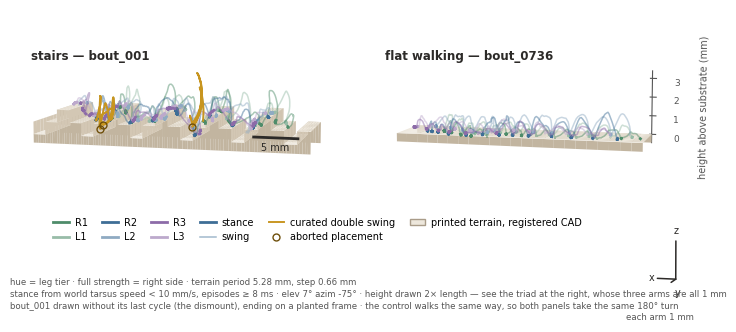


wrote /home/user/3D_tracking_paper/stairs_v2/walk_3d_illustration.svg | .pdf | .png  —  bout_001 (15 cycles) against flat bout_0736 (12 cycles, cropped to 12)
  1 mm draws as  x 1.00 : y 0.29 : z 2.05  (relative to x) — z is stretched 2× and y is
  nearly edge-on at azim -75°, so distances along y cannot be read off this view.
  fully vector: text stays text, nothing rasterised, every trace and tread face
  selectable. No axis box -- the bar is the scale, the caption carries the rest.


In [ ]:
# ---- FIGURE: the walk illustration, stairs vs flat, as editable SVG ----
# Hue = leg tier, full strength = right side. Both panels take the same 180 deg turn, so
# each animal keeps its handedness and the two read consistently. svg.fonttype='none'
# keeps text as text; nothing is rasterised.
ILLUS_ELEV, ILLUS_AZIM = 7, -75         # the grazing view chosen for this figure
ILLUS_TIER_HUE = {'T1': '#4E8C6A', 'T2': '#3E6E96', 'T3': '#8C6BA8'}   # front, mid, hind
ILLUS_DARK_SIDE = 'right'               # which side keeps the full-strength hue
ILLUS_LIGHTEN = .42                     # the other side, mixed this far toward white
ILLUS_STANCE_LW, ILLUS_SWING_LW = 2.0, 1.1
ILLUS_SWING_ALPHA = .48
ILLUS_ZOOM = 1.30                       # more room now that the axis box is gone
ILLUS_GOLD, ILLUS_GOLD_DARK = '#C8951F', '#6E4F0C'
ILLUS_SCALE_MM = 5.0                    # length of the scale bar; 0 draws none
# Double swings are located by world x, where these legs have no stance: every frame-based
# rule picked the wrong episode, because the curated frame falls in the brief touch and any
# merge window wide enough to span it also swallows a normal stance.
DS_AT_X_MM = {
    ('bout_001', 'T1_right'): (17.0, 27.0),
    ('bout_001', 'T2_right'): (27.0,),
}
DS_X_TOL_MM = 1.5                       # slack when no episode straddles that x exactly
ILLUS_AXES_MM = 1.0                     # length of each arm of the triad, in mm
ILLUS_AXES_RECT = (.875, .035, .105, .30)   # figure fractions: clear of both panels
# z is drawn ILLUS_Z_EXAG x length; the triad declares it.
ILLUS_Z_EXAG = 2.0
ROTATE_TO_WALK_RIGHT = True             # False draws both in raw world x, walking leftwards

def _lighten(hexc, f):
    r, g, b = (int(hexc[i:i + 2], 16) for i in (1, 3, 5))
    return '#%02X%02X%02X' % tuple(int(v + (255 - v) * f) for v in (r, g, b))

def illus_colour(leg):
    return _lighten(ILLUS_TIER_HUE[leg[:2]], 0.0 if leg.endswith(ILLUS_DARK_SIDE)
                    else ILLUS_LIGHTEN)

def _illus_proj_mm():
    """How long 1 mm draws along each axis on the page, relative to x, in this projection."""
    _e, _a = np.radians(ILLUS_ELEV), np.radians(ILLUS_AZIM)
    def _scr(v):
        _x, _y, _z = v
        return (-_x * np.sin(_a) + _y * np.cos(_a),
                -(_x * np.cos(_a) + _y * np.sin(_a)) * np.sin(_e) + _z * np.cos(_e))
    _lx = np.hypot(*_scr((1, 0, 0)))
    return (1.0, np.hypot(*_scr((0, 1, 0))) / _lx,
            ILLUS_Z_EXAG * np.hypot(*_scr((0, 0, 1))) / _lx)

def _illus_gnomon(fig, rot, rect=ILLUS_AXES_RECT, L=ILLUS_AXES_MM):
    """A 1 mm triad outside the panels, in the figure's own projection.

    Same elev/azim and the same anisotropy as the scenes, so the three arms are all 1 mm
    and deliberately not the same length on the page. Turns with the panels.
    """
    gx = fig.add_axes(rect, projection='3d')
    lo, hi = -.30 * L, 1.30 * L
    gx.set_xlim(*((hi, lo) if rot else (lo, hi)))
    gx.set_ylim(*((hi, lo) if rot else (lo, hi)))
    gx.set_zlim(lo, hi)                            # the SAME span on all three, so that
    gx.set_box_aspect((1, 1, ILLUS_Z_EXAG))        # the box aspect alone sets the anisotropy
    gx.view_init(elev=ILLUS_ELEV, azim=ILLUS_AZIM)
    gx.set_axis_off()
    gx.patch.set_alpha(0)                          # no white block behind it
    for _v, _lab, _off in (((L, 0, 0), 'x', (.34, 0, 0)),
                           ((0, L, 0), 'y', (-.34, .10, -.24)),
                           ((0, 0, L), 'z', (0, 0, .26))):
        gx.plot([0, _v[0]], [0, _v[1]], [0, _v[2]], '-', color='#2C2A28', lw=1.1,
                solid_capstyle='round')[0].set_clip_on(False)
        gx.text(_v[0] + _off[0] * L, _v[1] + _off[1] * L, _v[2] + _off[2] * L, _lab,
                fontsize=7, color='#2C2A28', ha='center', va='center')
    fig.text(rect[0], rect[1] - .035, f'each arm {ILLUS_AXES_MM:g} mm', fontsize=6.2,
             color='#555555', ha='left', va='top')
    return gx

def _illus_scene(ax, g, terrain, mark_doubles=False, bout=None, scale_bar=False,
                 z_axis=False):
    X = np.concatenate([g[f'{l}_x_world_mm'].values for l in LEGS]).astype(float)
    Y = np.concatenate([g[f'{l}_y_world_mm'].values for l in LEGS]).astype(float)
    base = TERRAIN_Z0 if terrain == 'stairs' else terrain
    x0, x1 = np.nanmin(X) - .6, np.nanmax(X) + .6
    y0, y1 = np.nanmin(Y) - .4, np.nanmax(Y) + .4
    if terrain == 'stairs':
        XX, YY, ZZ, CC, sk = _terrain_mesh(x0, x1, y0, y1, z_off=base)
        surf = dict(facecolors=CC)
    else:
        XX, YY, ZZ, sk = _flat_mesh(x0, x1, y0, y1, 0.0)
        surf = dict(color=D3_TREAD_C)
    for _sx, _sy, _sz in sk:
        ax.plot_surface(_sx, _sy, _sz, color=D3_SIDE_C, shade=False, rstride=1, cstride=1,
                        linewidth=0, zorder=0).set_clip_on(False)
    ax.plot_surface(XX, YY, ZZ, shade=False, rstride=1, cstride=1, linewidth=0, zorder=0,
                    **surf).set_clip_on(False)
    for l in LEGS:
        st = np.nan_to_num(g[f'{l}_swing_stance'].values, nan=0) > .5
        p = np.stack([g[f'{l}_x_world_mm'].values, g[f'{l}_y_world_mm'].values,
                      g[f'{l}_z_world_mm'].values - base], 1).astype(float)
        col = illus_colour(l)
        for mask, lw, al in ((~st, ILLUS_SWING_LW, ILLUS_SWING_ALPHA),
                             (st, ILLUS_STANCE_LW, 1.0)):
            q = np.where(mask[:, None], p, np.nan)
            for _ln in ax.plot(q[:, 0], q[:, 1], q[:, 2], '-', color=col, lw=lw, alpha=al,
                               zorder=5):
                _ln.set_clip_on(False)
        if mark_doubles:
            _xw = g[f'{l}_x_world_mm'].values.astype(float)
            for (_b, _l), _xs in DS_AT_X_MM.items():
                if _b != bout or _l != l:
                    continue
                runs = _runs(~st)
                if not len(runs):
                    continue
                for _x in _xs:
                    _hit = [r for r in runs
                            if np.nanmin(_xw[r[0]:r[1]]) - DS_X_TOL_MM <= _x
                            <= np.nanmax(_xw[r[0]:r[1]]) + DS_X_TOL_MM]
                    if not _hit:
                        print(f'    !! {_b} {_l}: no swing episode reaches x = {_x:.0f} mm; '
                              f'nothing marked there')
                        continue
                    a_, b_ = max(_hit, key=lambda r: r[1] - r[0])   # the long one, if two
                    seg = p[a_:b_]
                    print(f'    {_b} {_l} @ x {_x:.0f} mm: swing {a_}-{b_}, '
                          f'{(b_ - a_) / FPS * 1000:.0f} ms, x '
                          f'{np.nanmin(_xw[a_:b_]):.1f}-{np.nanmax(_xw[a_:b_]):.1f} mm')
                    ax.plot(seg[:, 0], seg[:, 1], seg[:, 2], '-', color=ILLUS_GOLD,
                            lw=ILLUS_SWING_LW * 1.25, zorder=7,
                            solid_capstyle='round')[0].set_clip_on(False)
                    # the aborted placement: the dip inside the episode, ends excluded
                    _mid = seg[len(seg) // 5: -len(seg) // 5] if len(seg) > 10 else seg
                    _tr = _mid[int(np.argmin(_mid[:, 2]))]
                    ax.plot([_tr[0]], [_tr[1]], [_tr[2]], 'o', mfc='none',
                            mec=ILLUS_GOLD_DARK, ms=5, mew=1.0,
                            zorder=8)[0].set_clip_on(False)
    rot = (ROTATE_TO_WALK_RIGHT
           and np.nanmedian(np.diff(g[f'{LEGS[0]}_x_world_mm'].values.astype(float))) < 0)
    if scale_bar and ILLUS_SCALE_MM:
        # the only ruler left: a bar on the substrate, at the near edge, out of the traces
        _xa = x0 + .8
        _xb = _xa + ILLUS_SCALE_MM
        _yb, _zb = y0 + .25, -D3_BASE_MM * .55
        ax.plot([_xa, _xb], [_yb, _yb], [_zb, _zb], '-', color='#2C2A28', lw=2.0,
                solid_capstyle='butt', zorder=9)[0].set_clip_on(False)
        ax.text((_xa + _xb) / 2, _yb, _zb - .28, f'{ILLUS_SCALE_MM:.0f} mm', fontsize=7,
                color='#2C2A28', ha='center', va='top', zorder=9)
    ax.set_xlim(*((x1, x0) if rot else (x0, x1)))
    ax.set_ylim(*((y1, y0) if rot else (y0, y1)))
    ax.set_zlim(-D3_BASE_MM, D3_ZMAX_MM)
    ax.set_box_aspect((x1 - x0, y1 - y0, (D3_ZMAX_MM + D3_BASE_MM) * ILLUS_Z_EXAG),
                      zoom=ILLUS_ZOOM)
    ax.view_init(elev=ILLUS_ELEV, azim=ILLUS_AZIM)
    if not z_axis:
        ax.set_axis_off()                # no panes, no grid, no ticks, no axis titles
    else:
        # everything off EXCEPT the height axis, which is the only way to read a scene whose
        # vertical is stretched: panes and grid gone, x and y stripped to nothing, z kept
        for _a in (ax.xaxis, ax.yaxis, ax.zaxis):
            _a.pane.fill = False
            _a.pane.set_edgecolor('none')
            _a._axinfo['grid'].update(color=(1, 1, 1, 0))
        for _a, _set in ((ax.xaxis, ax.set_xticks), (ax.yaxis, ax.set_yticks)):
            _a.line.set_color('none')
            _a.set_tick_params(colors='none', length=0)
            _set([])
        ax.set_xlabel(''); ax.set_ylabel('')
        ax.zaxis.line.set_color('#555555')
        ax.zaxis.set_tick_params(colors='#555555', labelsize=6.5, pad=-1)
        ax.set_zticks(np.arange(0, D3_ZMAX_MM, 1.0))
        ax.set_zlabel('height above substrate (mm)', fontsize=7, color='#555555',
                      labelpad=-6)
    return rot

def walk_illustration(ref=D3_REF_BOUT, out='walk_3d_illustration'):
    """The chosen plate, both conditions, written as SVG / PDF / PNG for editing."""
    import matplotlib as _mpl
    _rc = {k: _mpl.rcParams[k] for k in ('svg.fonttype', 'pdf.fonttype', 'ps.fonttype',
                                         'font.size')}
    _mpl.rcParams.update({'svg.fonttype': 'none', 'pdf.fonttype': 42, 'ps.fonttype': 42,
                          'font.size': 8})
    gs = _fig_trim(df_valid[df_valid.bout_id == ref].sort_values('frame'), ref)
    n_ref = gs.step_cycle_id.dropna().nunique()
    fb, fn = _match_flat_bout(n_ref, _travel_sign(gs))
    gf = DF['flat'][DF['flat'].bout_id == fb].sort_values('frame')
    keep = set(np.sort(_cycles_of(DF['flat'], fb))[:n_ref])
    gf = gf[gf.step_cycle_id.isin(keep)]
    zf = float(np.nanmedian(np.concatenate(
        [gf[f'{l}_z_world_mm'].values[np.nan_to_num(gf[f'{l}_swing_stance'].values, nan=0) > .5]
         for l in LEGS])))
    fig = plt.figure(figsize=(180 / 25.4, 70 / 25.4))
    for i, (g, terr, ttl, mk) in enumerate(((gs, 'stairs', f'stairs — {ref}', True),
                                            (gf, zf, f'flat walking — {fb}', False))):
        ax = fig.add_subplot(1, 2, i + 1, projection='3d')
        _rot = _illus_scene(ax, g, terr, mark_doubles=mk, bout=ref, scale_bar=(i == 0),
                            z_axis=(i == 1))
        # with the axis box gone the axes bbox is much larger than the drawn scene, so a
        # title anchored to the axes floats far above it: place the labels on the figure
        fig.text(.035 + .5 * i, .955, ttl, fontsize=8.5, color='#2C2A28', ha='left',
                 va='top', weight='bold')
    _keys = [mpl.lines.Line2D([], [], color=illus_colour(l), lw=2.0, label=LEG_LABELS[l])
             for l in ('T1_right', 'T1_left', 'T2_right', 'T2_left', 'T3_right', 'T3_left')]
    _keys += [mpl.lines.Line2D([], [], color='#3E6E96', lw=ILLUS_STANCE_LW, label='stance'),
              mpl.lines.Line2D([], [], color='#3E6E96', lw=ILLUS_SWING_LW,
                               alpha=ILLUS_SWING_ALPHA, label='swing'),
              mpl.lines.Line2D([], [], color=ILLUS_GOLD, lw=ILLUS_SWING_LW * 1.25,
                               label='curated double swing'),
              mpl.lines.Line2D([], [], color=ILLUS_GOLD_DARK, lw=0, marker='o', mfc='none',
                               ms=5, label='aborted placement'),
              mpl.patches.Patch(facecolor=D3_TREAD_C, edgecolor='#A99C89',
                                label='printed terrain, registered CAD')]
    # shifted left of centre to keep the bottom-right corner free for the triad
    fig.legend(handles=_keys, loc='lower center', bbox_to_anchor=(.44, .225), ncol=6,
               frameon=False, fontsize=7, handlelength=1.6, columnspacing=1.5,
               handletextpad=.6)
    fig.text(.006, .006,
             f'hue = leg tier · full strength = {ILLUS_DARK_SIDE} side · terrain period '
             f'{TERRAIN_PERIOD_MM:.2f} mm, step {TERRAIN_STEP_MM:.2f} mm\n'
             f'stance from world tarsus speed < {HYST_IN_MM_S:.0f} mm/s, episodes ≥ '
             f'{HYST_MIN_MS:.0f} ms · elev {ILLUS_ELEV}° azim {ILLUS_AZIM}° · '
             + ('true scale' if ILLUS_Z_EXAG == 1 else
                f'height drawn {ILLUS_Z_EXAG:g}× length — see the triad at the right, '
                f'whose three arms are all 1 mm') + '\n'
             f'{ref} drawn without its last cycle (the dismount), ending on a planted frame · '
             f'the control walks the same way, so both panels take the same 180° turn',
             fontsize=6.2, color='#555555', va='bottom', linespacing=1.45)
    _illus_gnomon(fig, _rot)
    fig.subplots_adjust(left=.01, right=.96, top=1.10, bottom=.38, wspace=.04)
    for _ext in ('svg', 'pdf', 'png'):
        fig.savefig(OUTPUT_DIR / f'{out}.{_ext}', dpi=300)
    plt.show()
    _mpl.rcParams.update(_rc)
    print(f'\nwrote {OUTPUT_DIR}/{out}.svg | .pdf | .png  —  {ref} ({n_ref} cycles) against '
          f'flat {fb} ({fn} cycles, cropped to {len(keep)})')
    _r = _illus_proj_mm()
    print(f'  1 mm draws as  x {_r[0]:.2f} : y {_r[1]:.2f} : z {_r[2]:.2f}  (relative to x) — '
          f'z is stretched {ILLUS_Z_EXAG:g}× and y is\n  nearly edge-on at azim '
          f'{ILLUS_AZIM}°, so distances along y cannot be read off this view.')
    print('  fully vector: text stays text, nothing rasterised, every trace and tread face')
    print('  selectable. No axis box -- the bar is the scale, the caption carries the rest.')
    return fig

_ = walk_illustration()
